# Partie 2 - Statistique Bivariée

In [3]:
# Imports de base
import pandas as pd
import matplotlib.pyplot as plt
import math

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Affichage plus lisible
pd.set_option("display.max_columns", None)

In [4]:
# Chargement du jeu de données bancaires : bank-additional-full.csv

bank_df = pd.read_csv("bank-additional-full.csv/bank-additional-full.csv", sep=";")
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#  CAS 1 — QUANTI ↔ QUANTI

In [5]:
numerical_variables = ["age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

###  Analyse de la corrélation entre les variables numériques


In [6]:
def compute_heat_map(df) :
    plt.figure(figsize=(12, 10))
    sns.heatmap(df.corr(numeric_only=True), annot=True)
    plt.show()


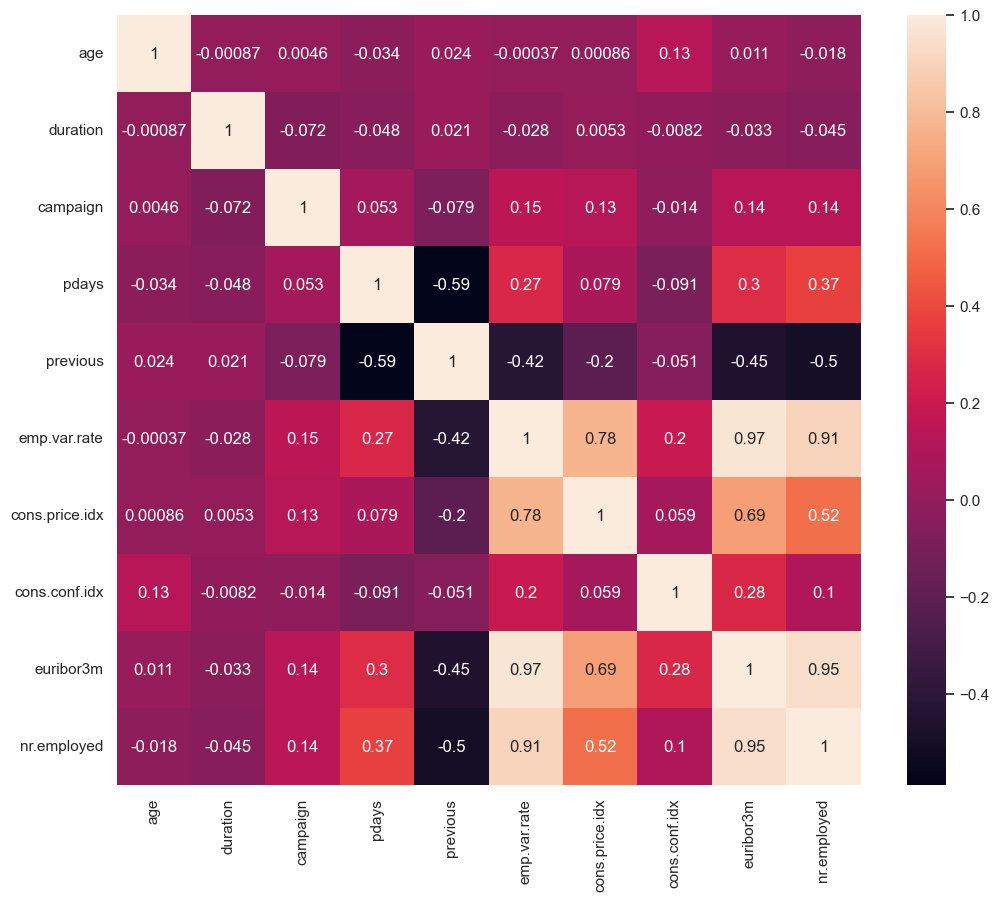

In [7]:
compute_heat_map(bank_df)

In [12]:
bank_df["y"] = bank_df["y"].map({"no": 0, "yes": 1}).astype(int)
bank_df.corr(numeric_only=True)["y"].sort_values(ascending=False)


y                 1.000000
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64

### Interprétation :

Les variables macroéconomiques présentent des corrélations significatives entre elles, ce qui s’explique par leur dépendance à des facteurs économiques communs et à la dimension temporelle du dataset. Cette colinéarité peut poser des problèmes pour les modèles linéaires en rendant l’interprétation des coefficients instable. En revanche, les modèles basés sur des arbres y sont moins sensibles. Une sélection de variables ou une réduction de dimension peut être envisagée selon le modèle utilisé.

In [10]:
def plot_pair_plot(df, numerical_vars) :
    sns.pairplot(data=df, vars=numerical_vars)
    plt.show()

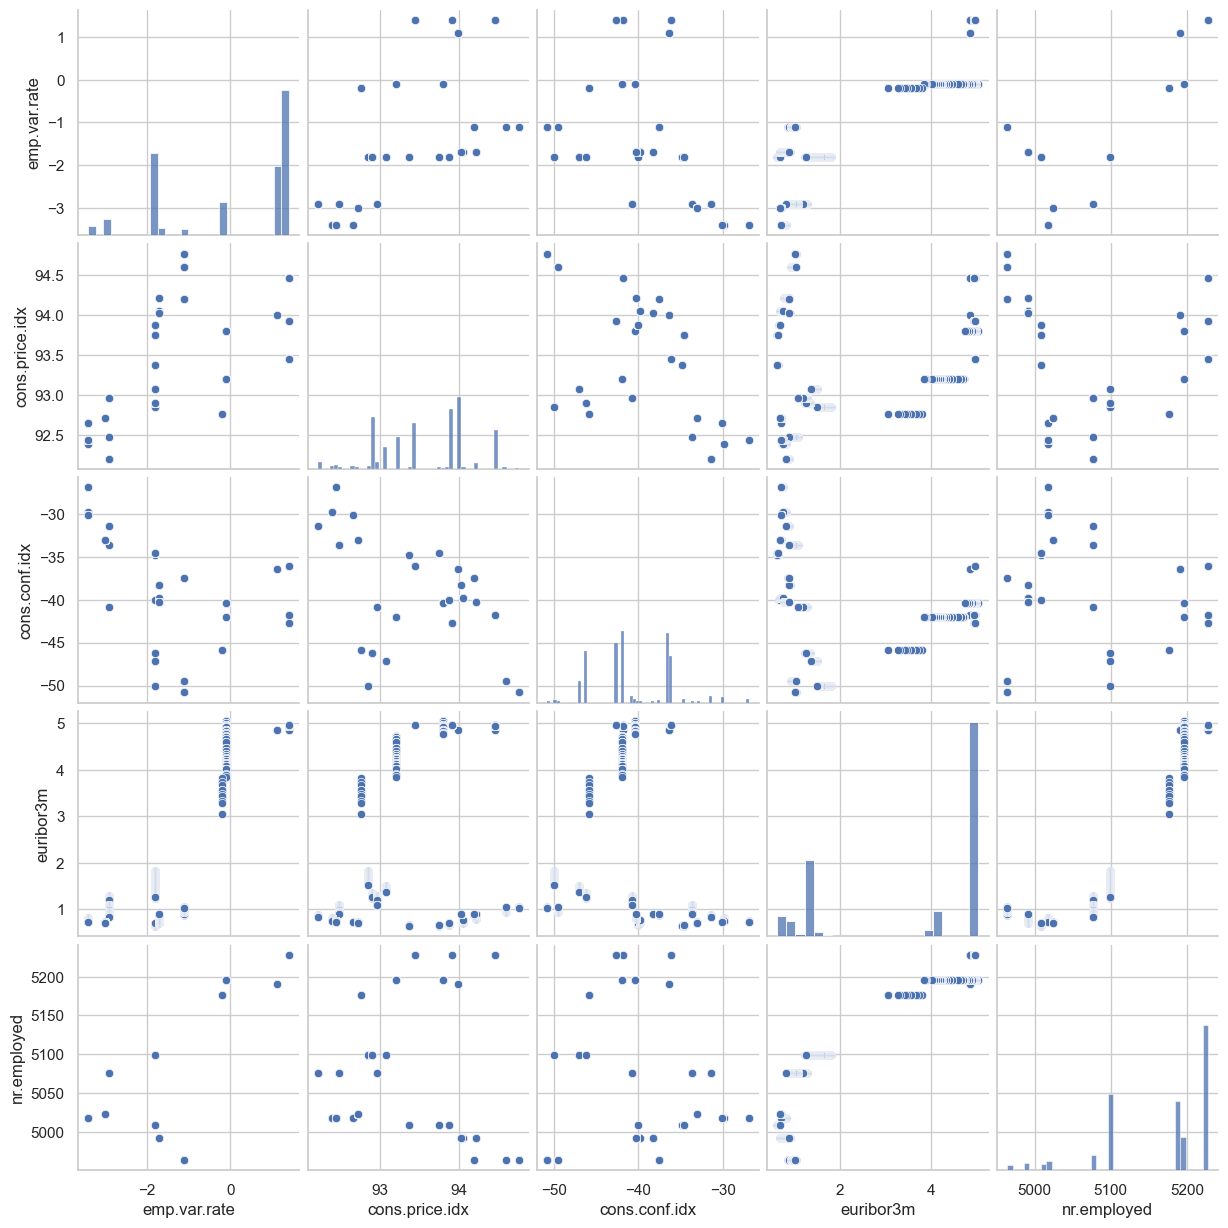

In [11]:
plot_pair_plot(bank_df, ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"])


#  CAS 2 — QUALI ↔ QUANTI

In [27]:
categorical_variables = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome", "y"]
num_variables = ["age", "campaign", "pdays", "previous"]

In [29]:
def compute_statistics_per_category(df, categorical_vars, numerical_vars) :
    for num_var in numerical_vars :
        print(f"Récapitulatifs des statistiques de la variable numérique {num_var}\n par modalité pour chaque variable catégorielle \n\n")
        for cat_var in categorical_vars :
            print(f"Récapitulatifs des statistiques par modalité de la variable {cat_var}\n")

            recap= df.groupby(cat_var)[num_var].agg(
                moyenne = "mean",
                mediane = "median",
                variance = "var",
                ecart_type = "std",
                minimum = "min",
                Q1 = lambda x: x.quantile(0.25),
                Q2 = "median",
                Q3 = lambda x: x.quantile(0.75),
                maximum = "max",
                IQR = lambda x: x.quantile(0.75) - x.quantile(0.25),
                etendue = lambda x: x.max() - x.min()
            )

            print(f"{recap}\n")
            

In [30]:
compute_statistics_per_category(bank_df, categorical_variables, num_variables)

Récapitulatifs des statistiques de la variable numérique age
 par modalité pour chaque variable catégorielle 


Récapitulatifs des statistiques par modalité de la variable job

                 moyenne  mediane    variance  ecart_type  minimum    Q1  \
job                                                                        
admin.         38.187296     36.0   79.337338    8.907151       20  31.0   
blue-collar    39.555760     39.0   77.922915    8.827396       20  33.0   
entrepreneur   41.723214     41.0   79.403062    8.910840       20  35.0   
housemaid      45.500000     45.0  116.450425   10.791220       21  37.0   
management     42.362859     42.0   86.561070    9.303820       21  35.0   
retired        62.027326     59.0  110.109201   10.493293       23  56.0   
self-employed  39.949331     39.0   88.781938    9.422417       21  32.0   
services       37.926430     36.0   81.337832    9.018749       20  31.0   
student        25.894857     25.0   24.913417    4.991334      

In [38]:
def plot_boxplot_per_category(df, categorical_vars, numerical_vars):

    for num_var in numerical_vars:

        n = len(categorical_vars)
        cols = 3  # nombre de colonnes (modifiable)
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = axes.flatten()

        for i, cat_var in enumerate(categorical_vars):
            sns.boxplot(x=cat_var, y=num_var, data=df, ax=axes[i])
            axes[i].set_title(f"{num_var} vs {cat_var}")
            axes[i].tick_params(axis='x', rotation=90)

        # supprimer les axes inutilisés
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Boxplots pour la variable {num_var}", fontsize=14)
        plt.tight_layout()
        plt.show()

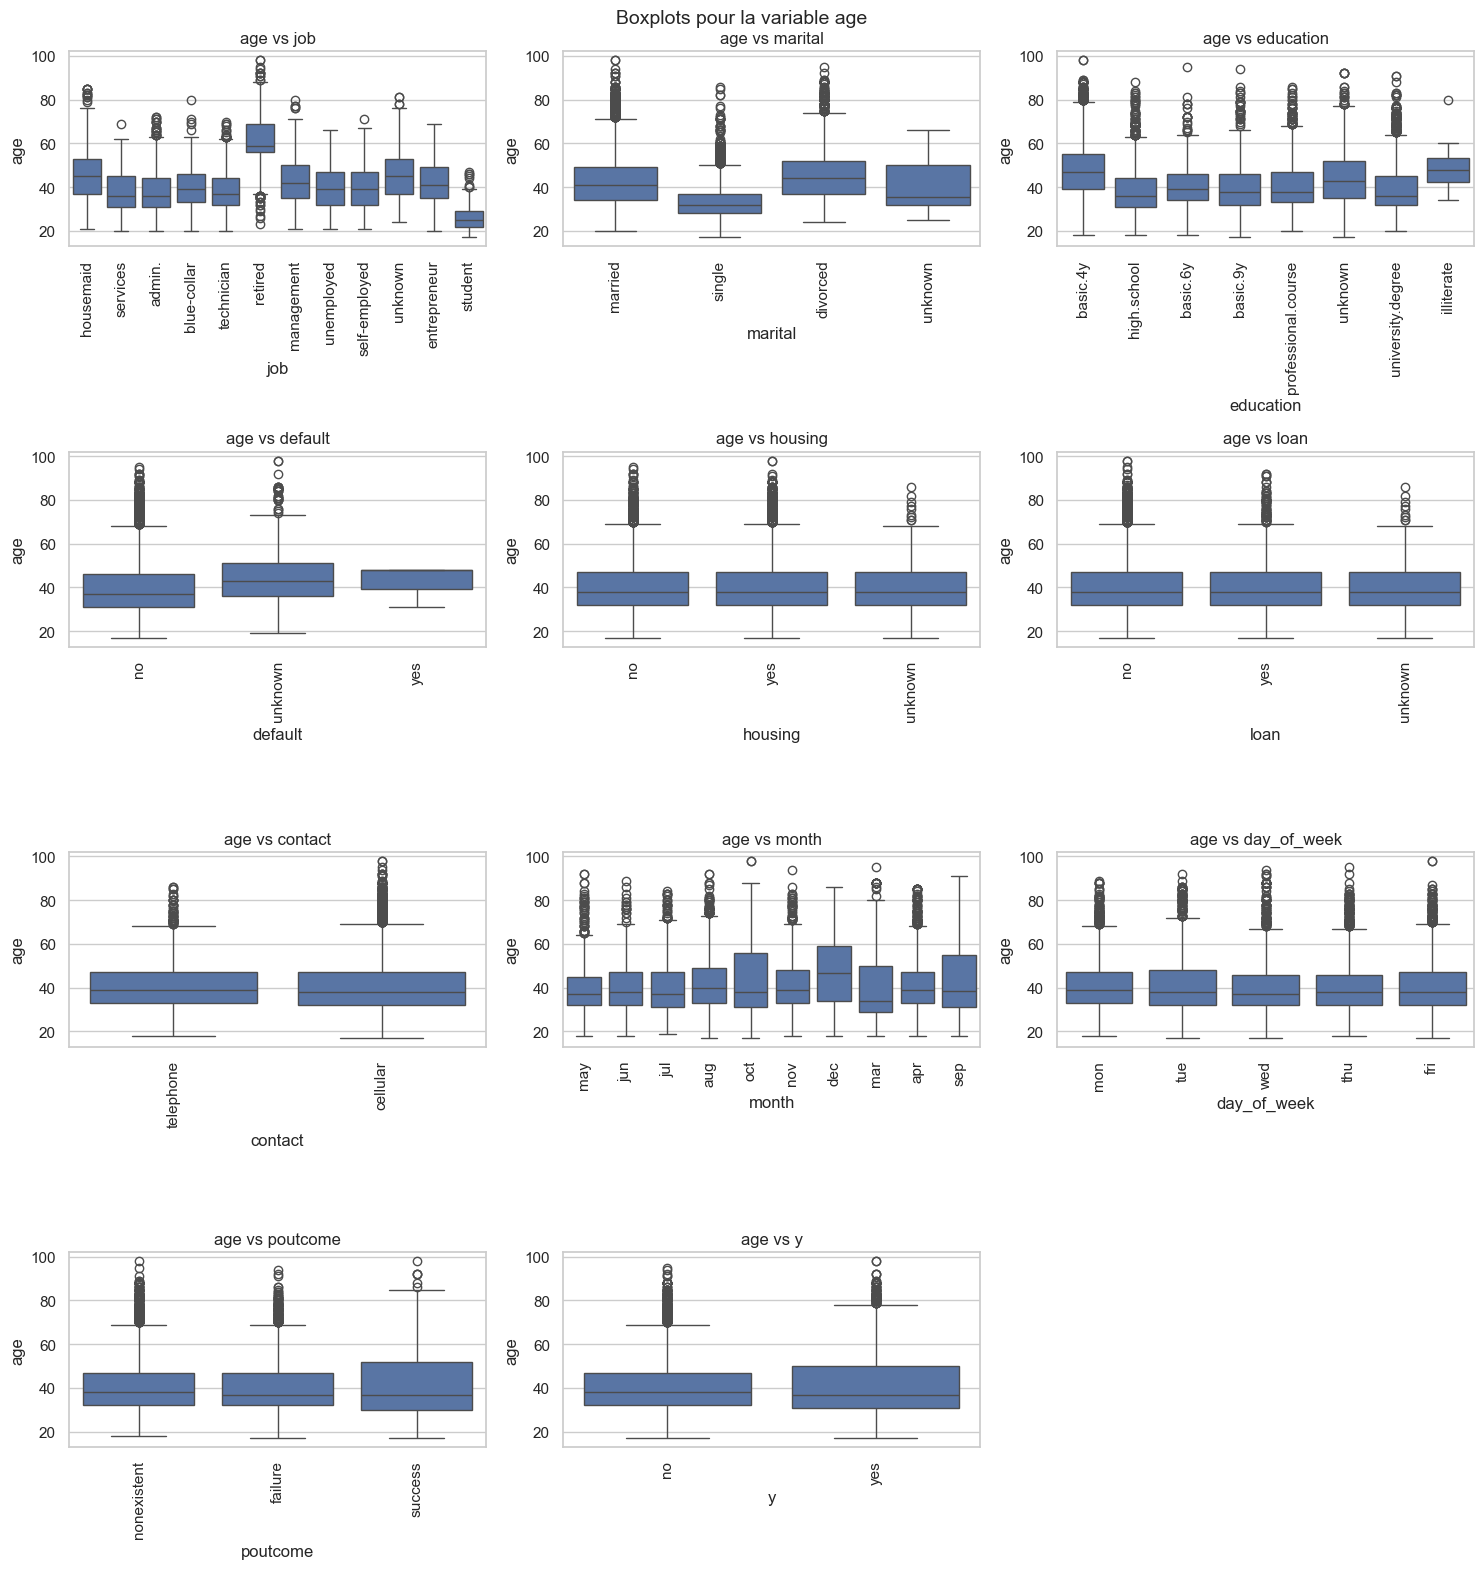

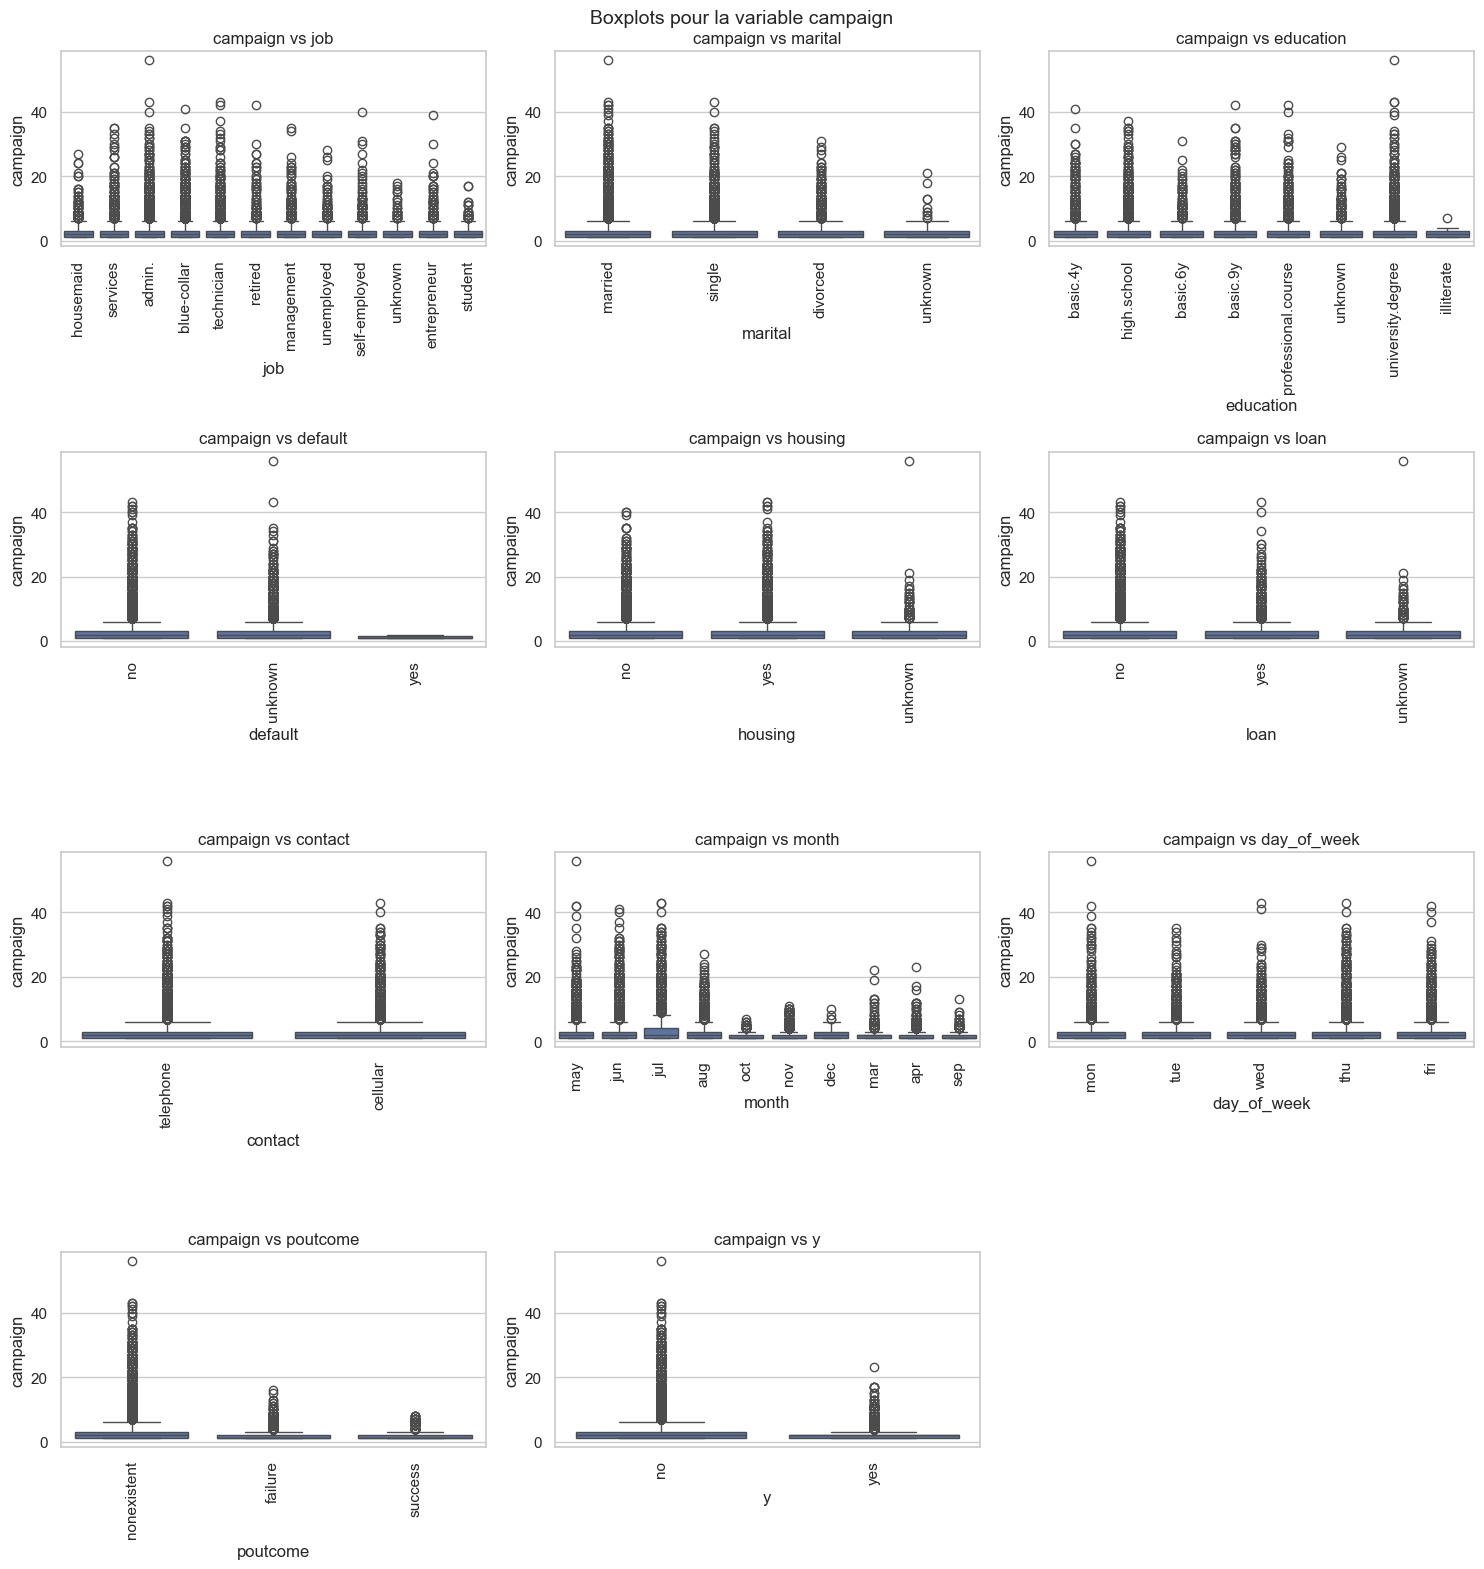

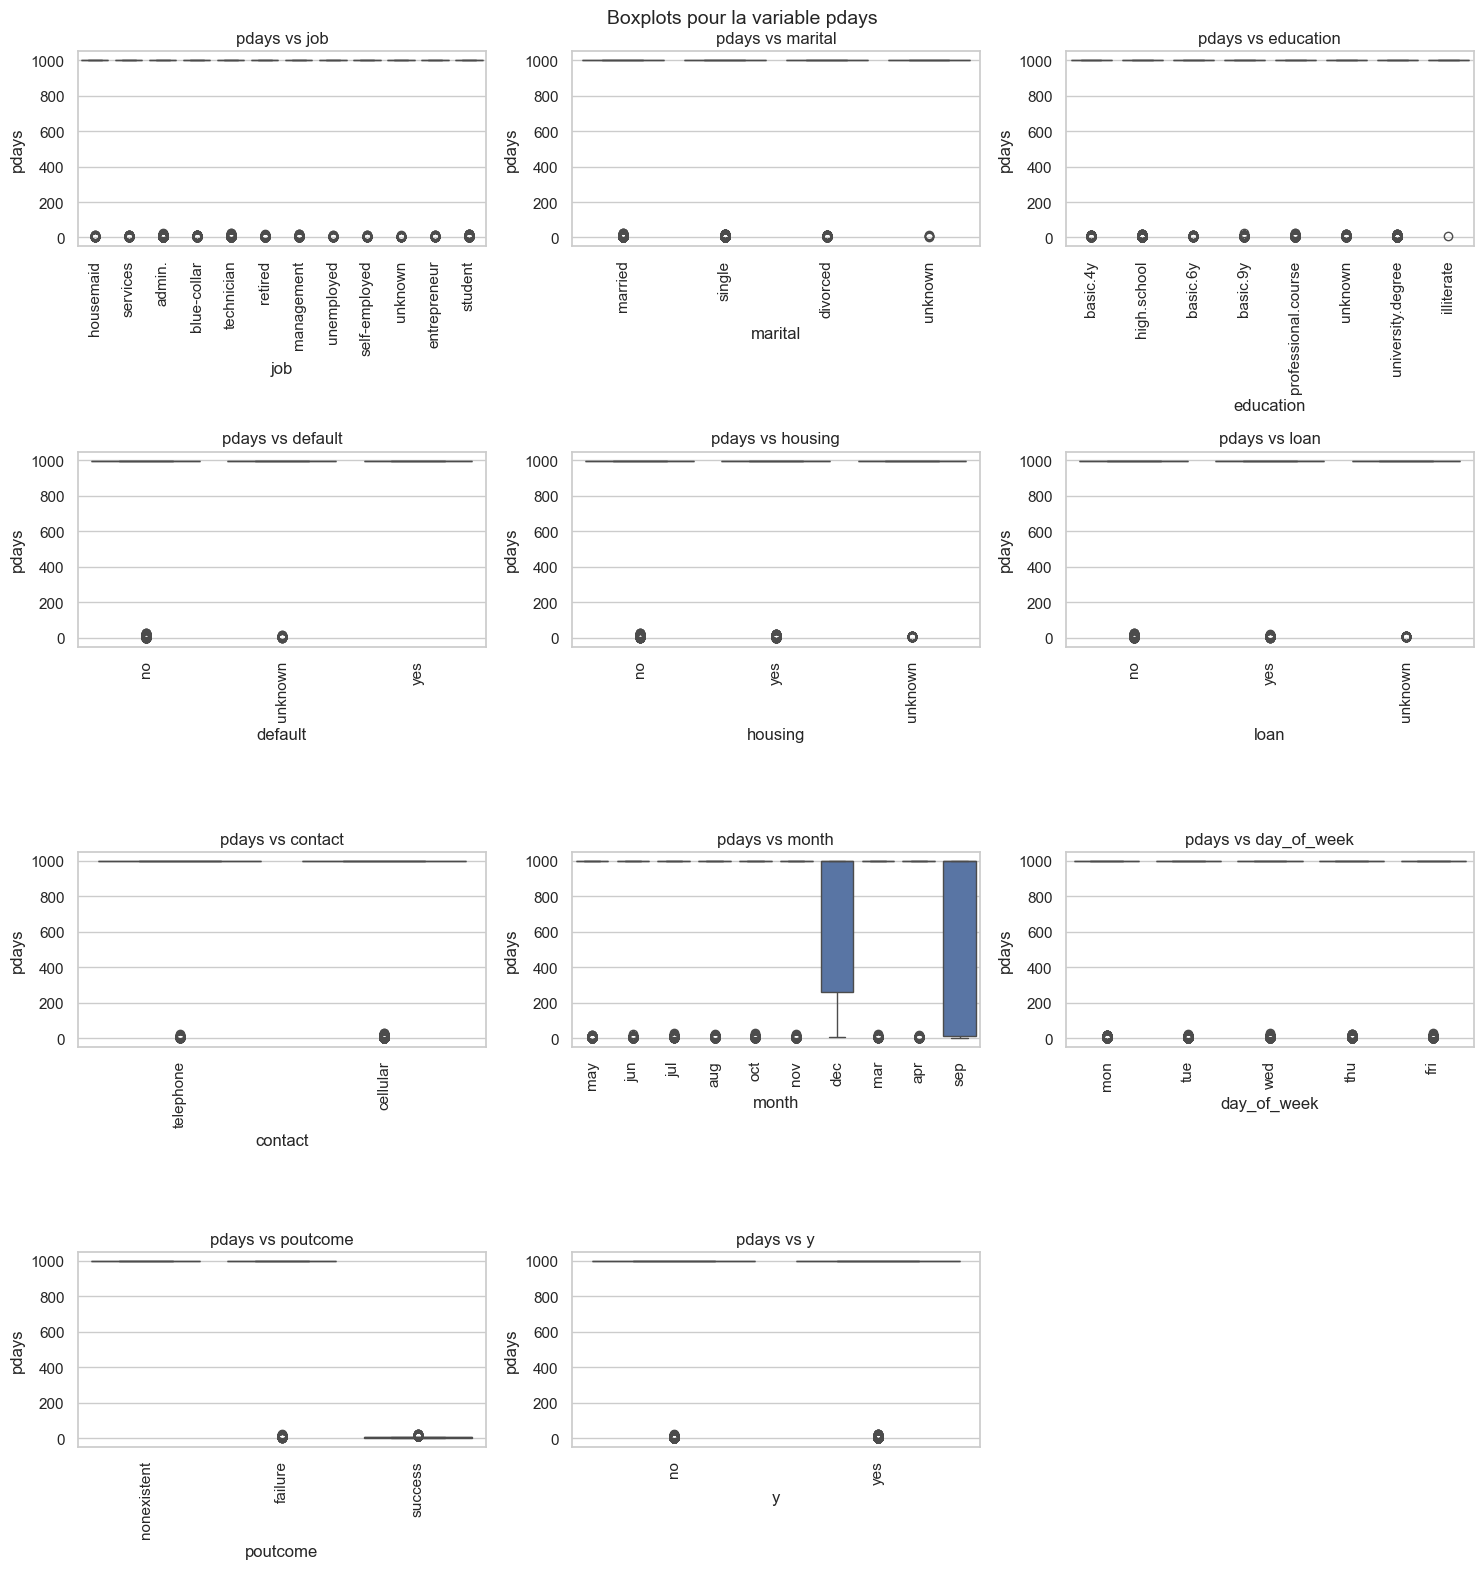

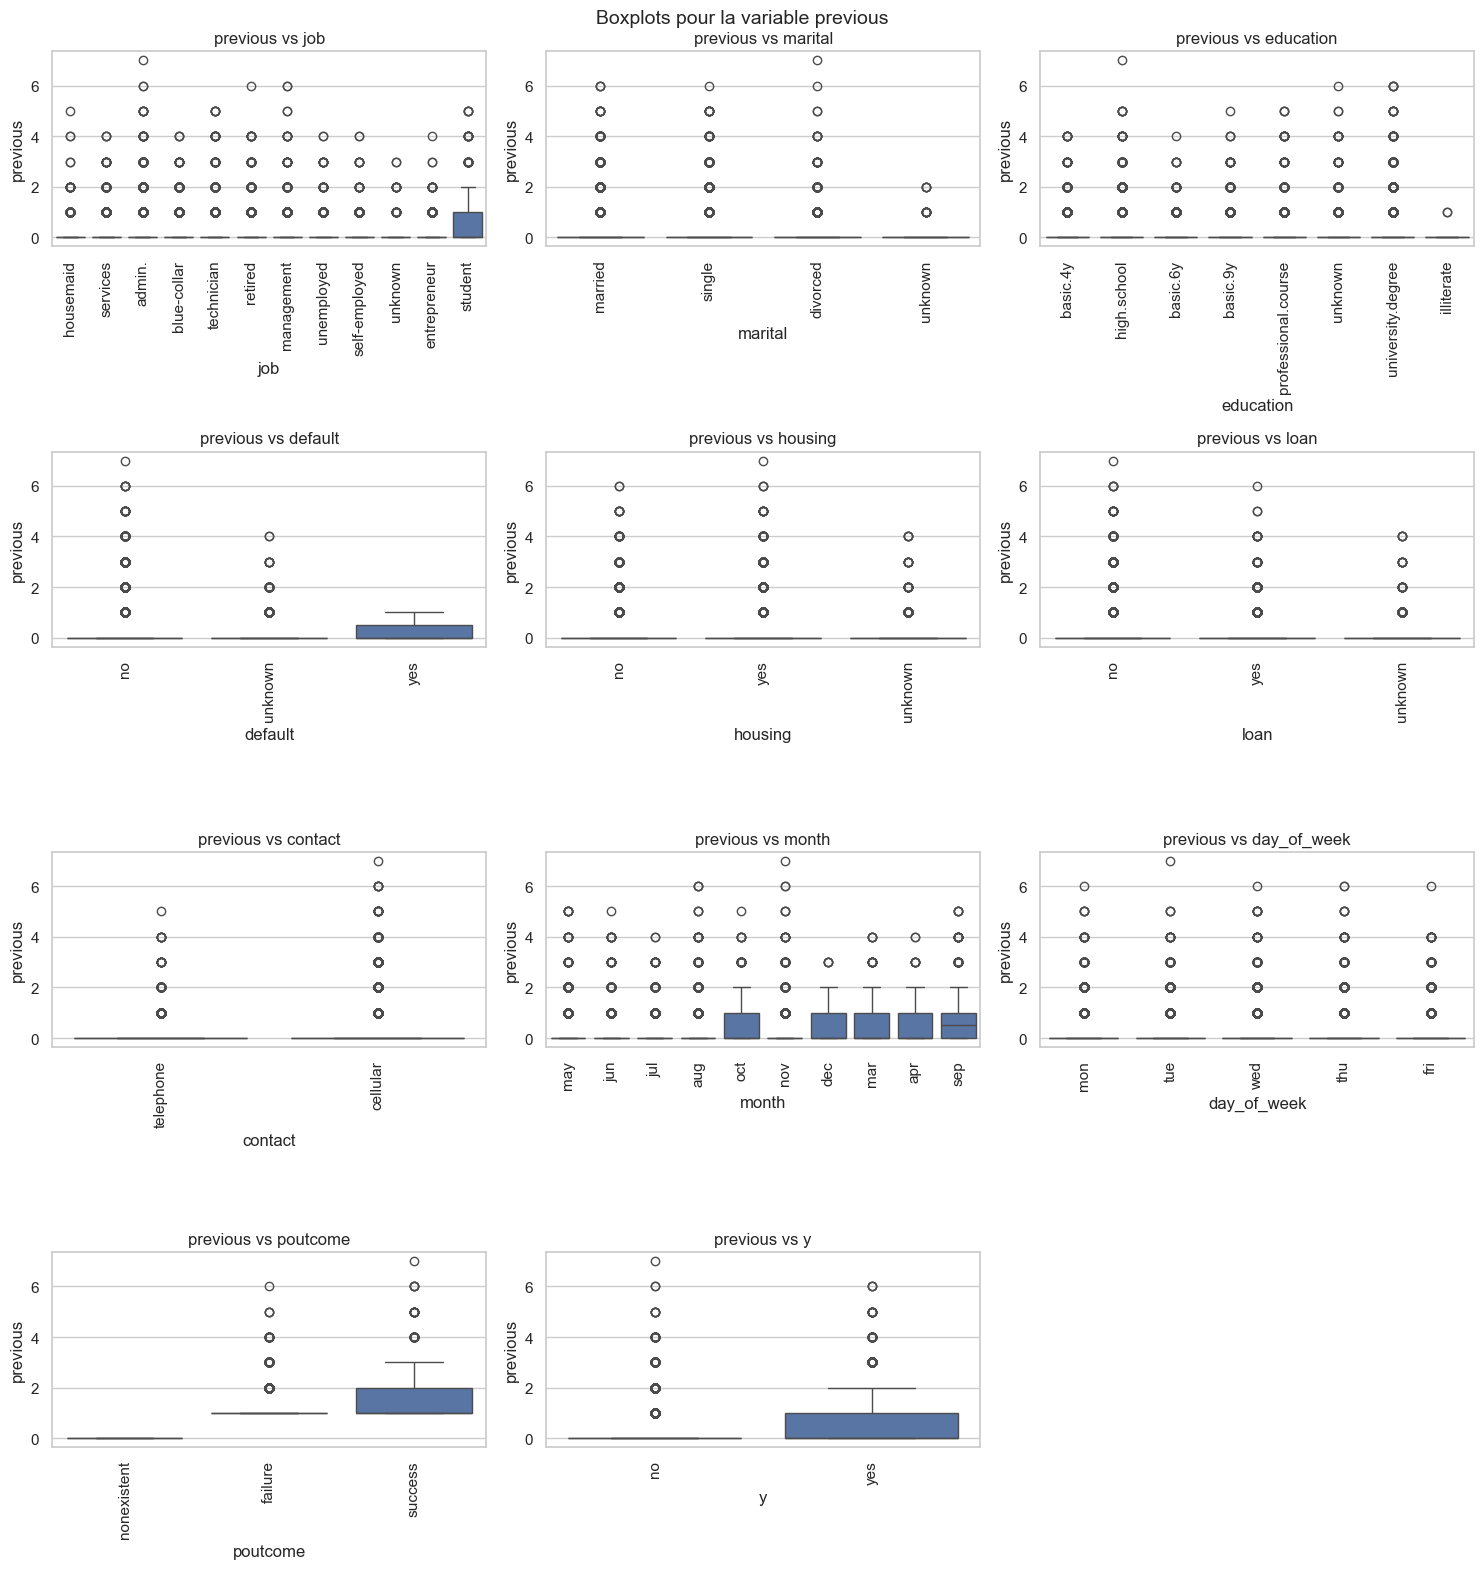

In [39]:
plot_boxplot_per_category(bank_df, categorical_variables, num_variables)

In [41]:
def plot_violinplot_per_category(df, categorical_vars, numerical_vars):

    for num_var in numerical_vars:

        n = len(categorical_vars)
        cols = 3  # nombre de colonnes (modifiable)
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = axes.flatten()

        for i, cat_var in enumerate(categorical_vars):
            sns.violinplot(x=cat_var, y=num_var, data=df, ax=axes[i])
            axes[i].set_title(f"{num_var} vs {cat_var}")
            axes[i].tick_params(axis='x', rotation=90)

        # supprimer les axes inutilisés
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Violinplots pour la variable {num_var}", fontsize=14)
        plt.tight_layout()
        plt.show()

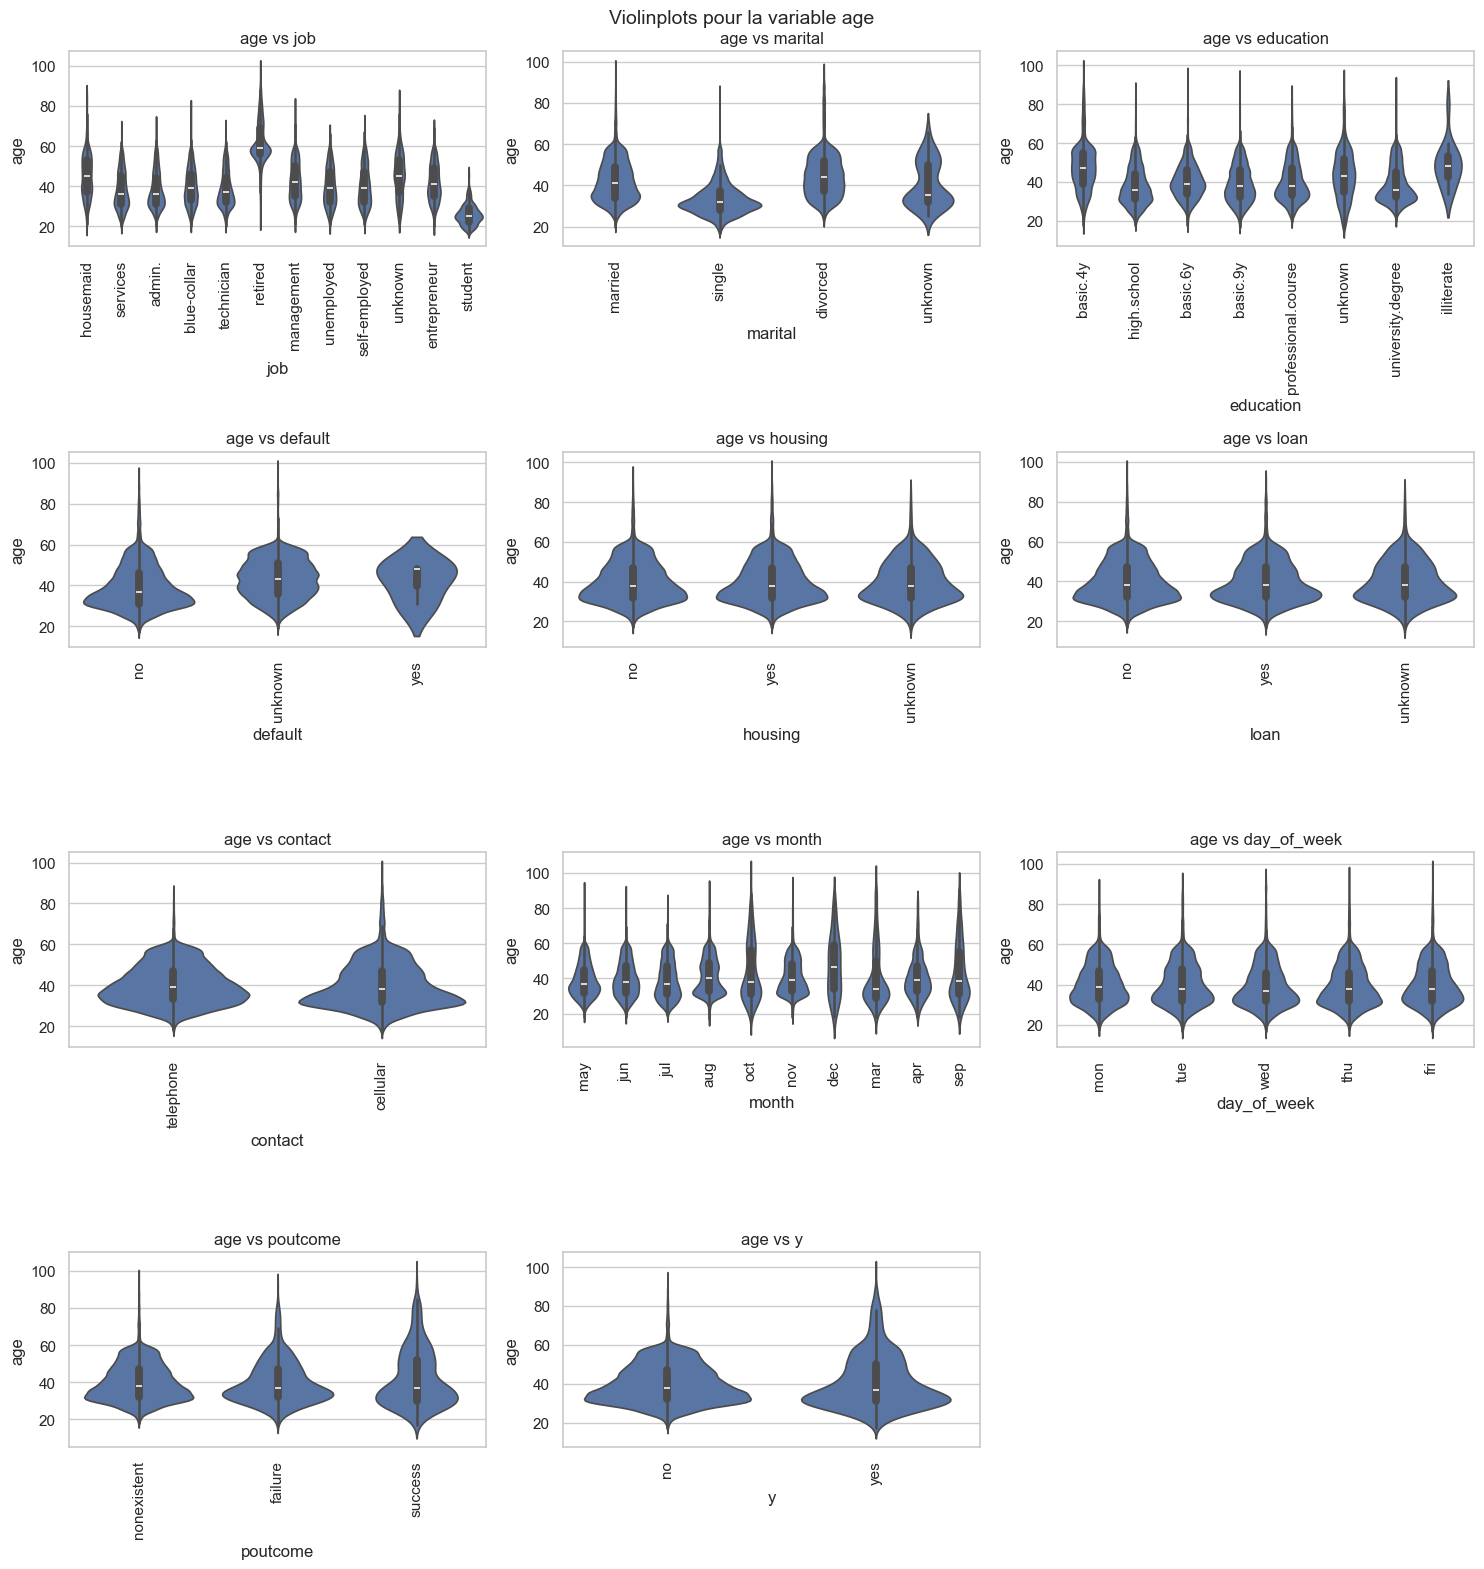

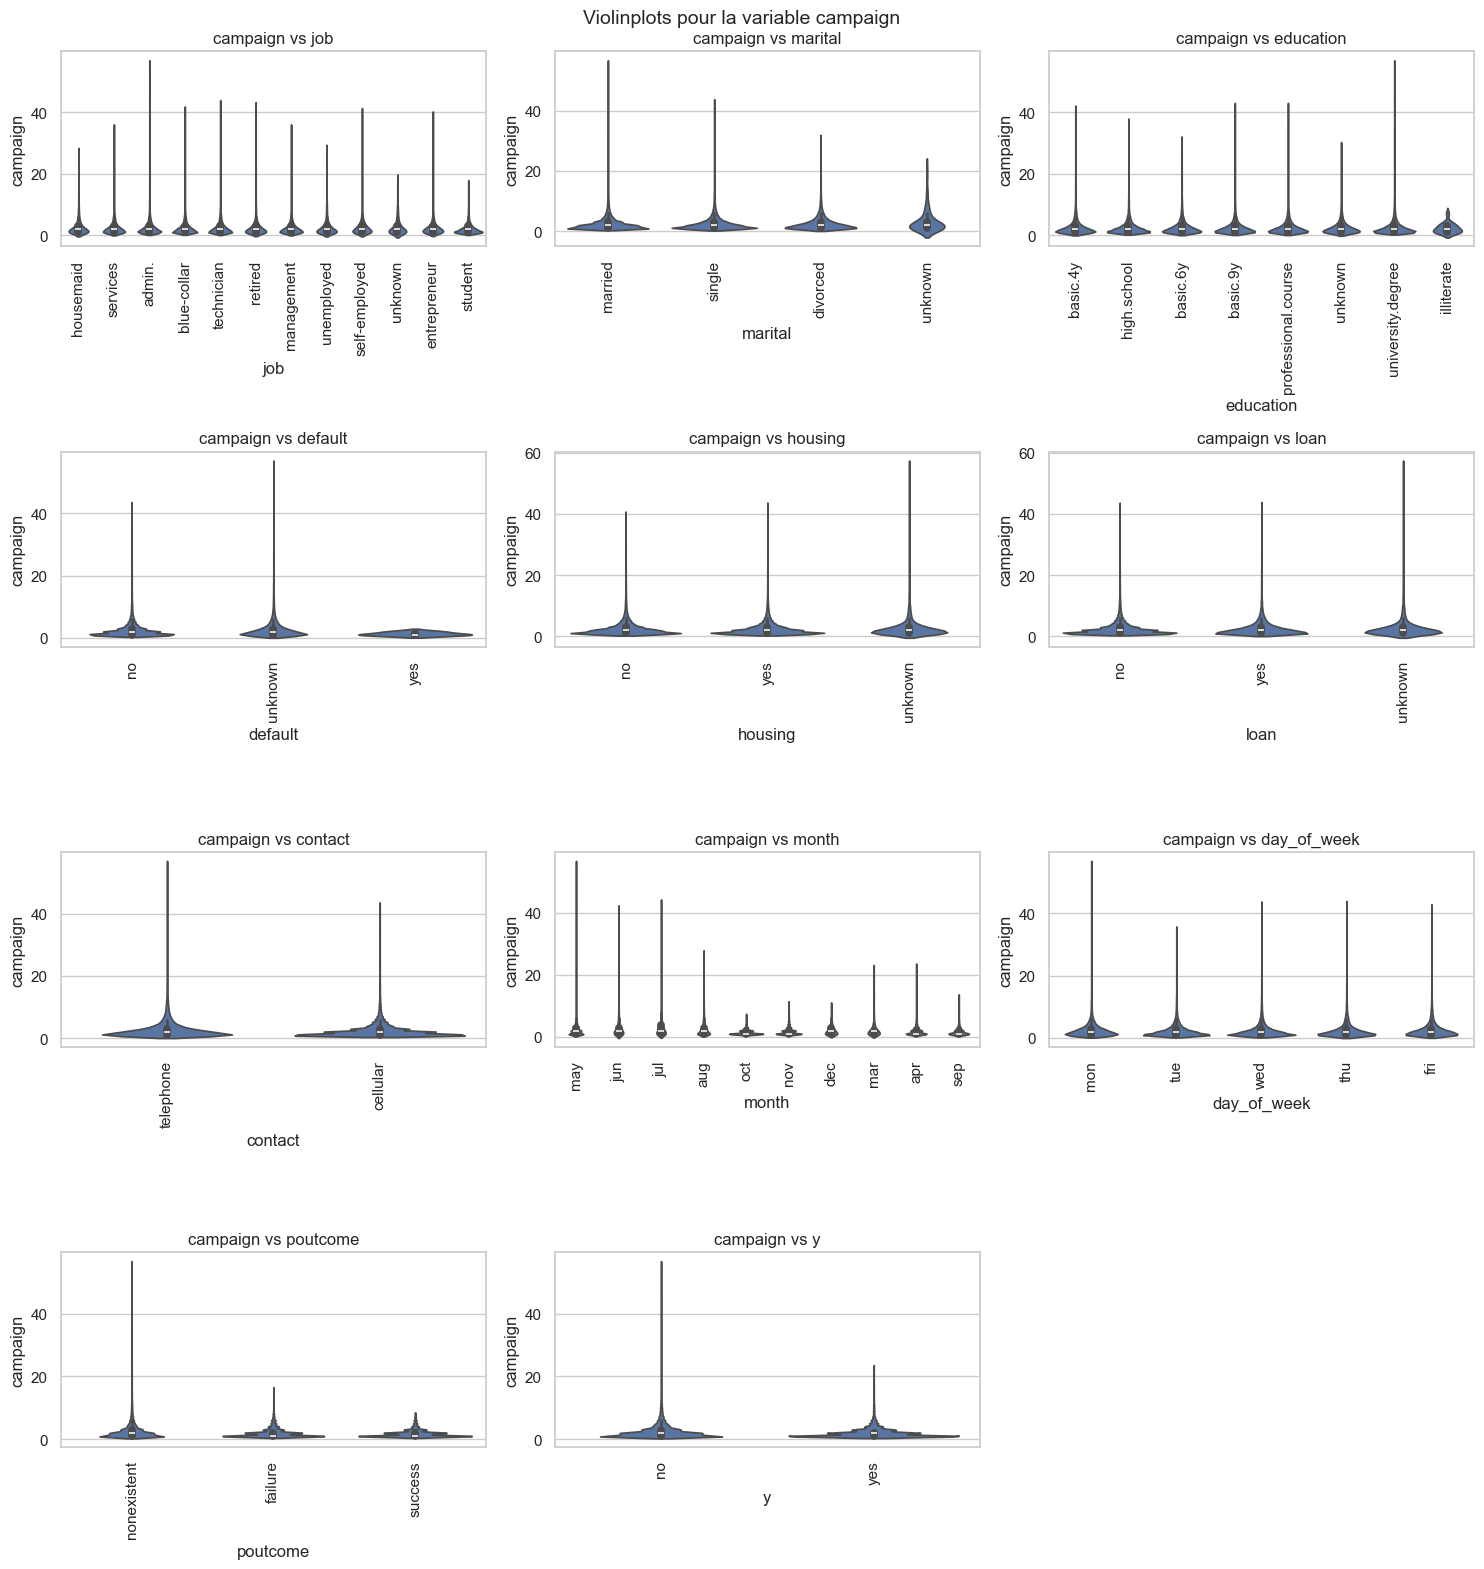

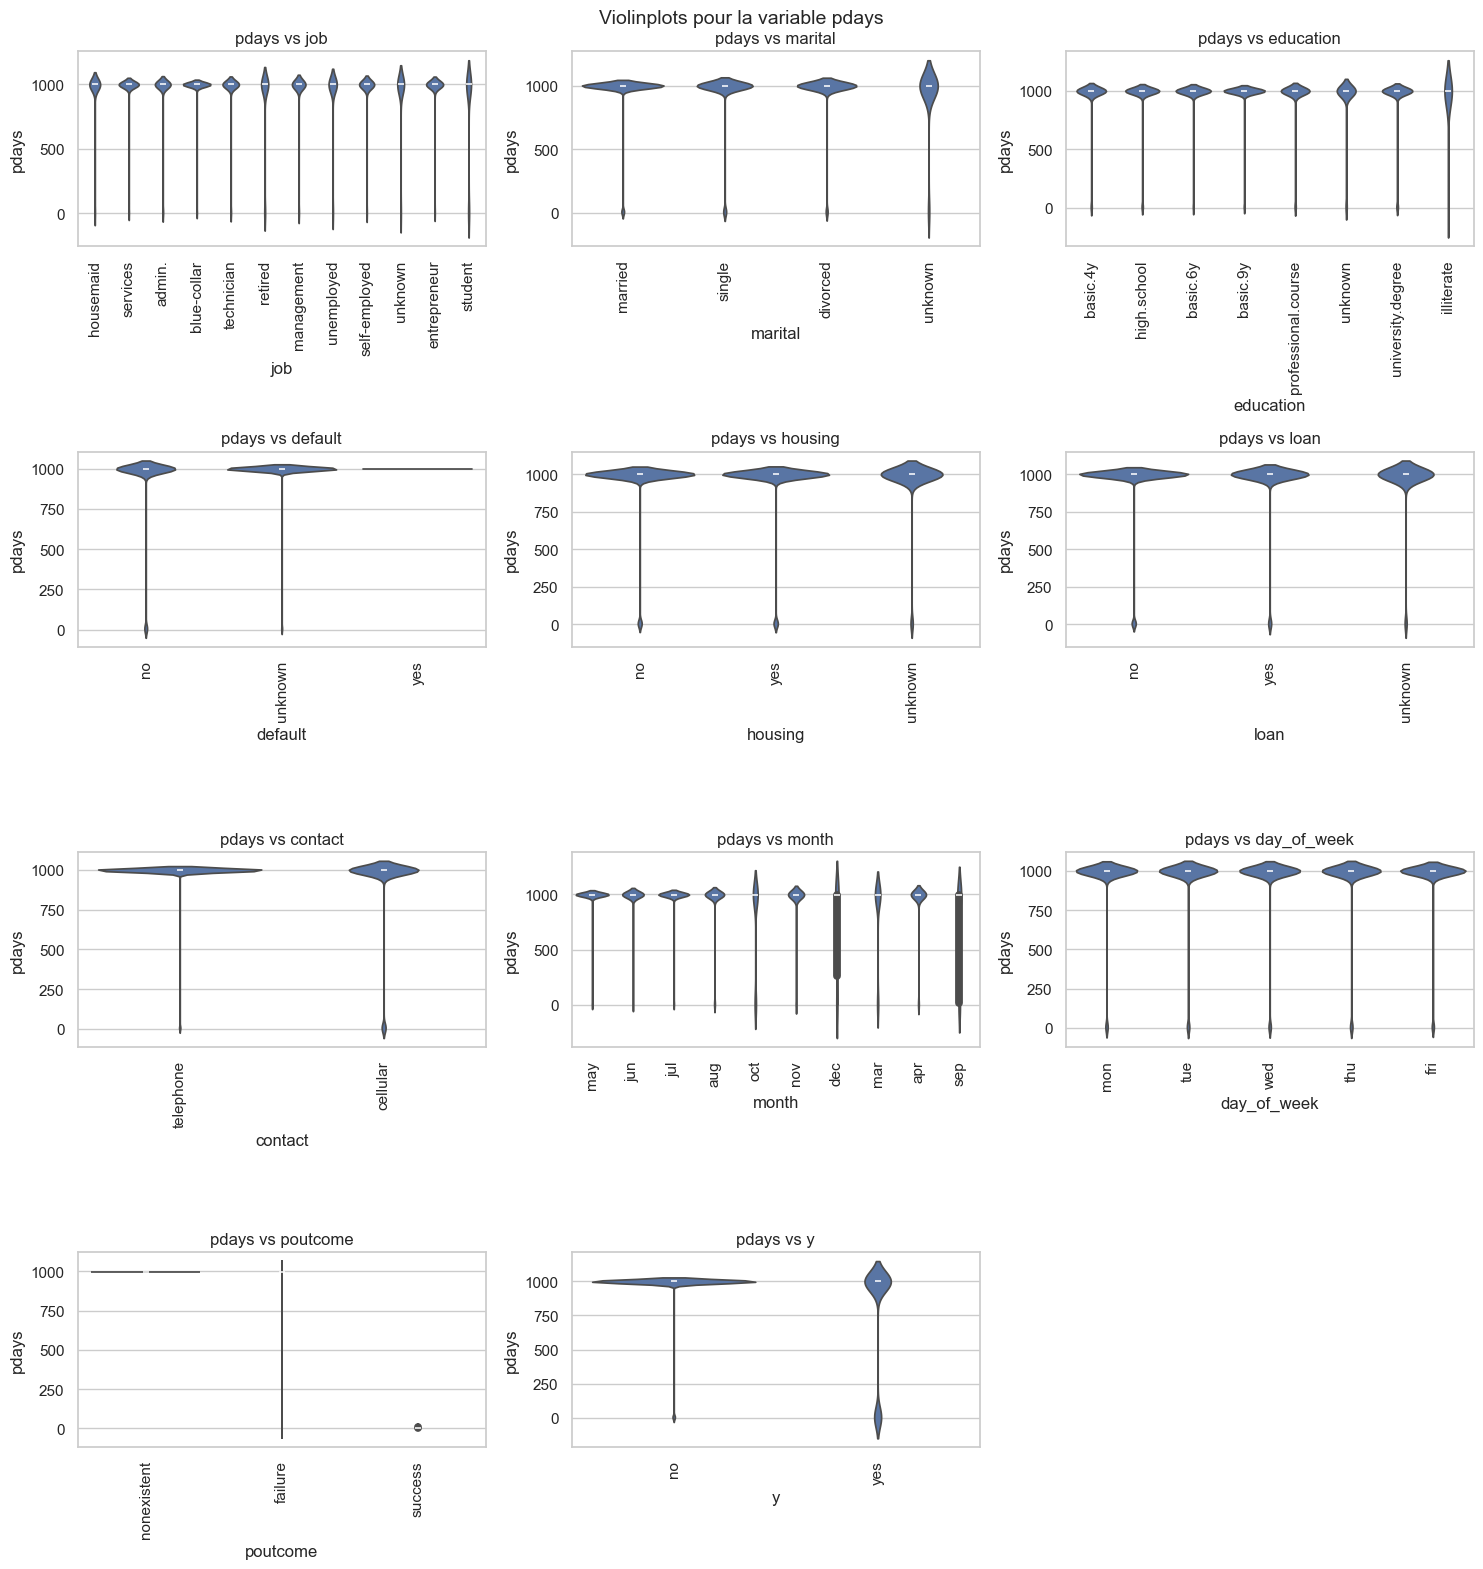

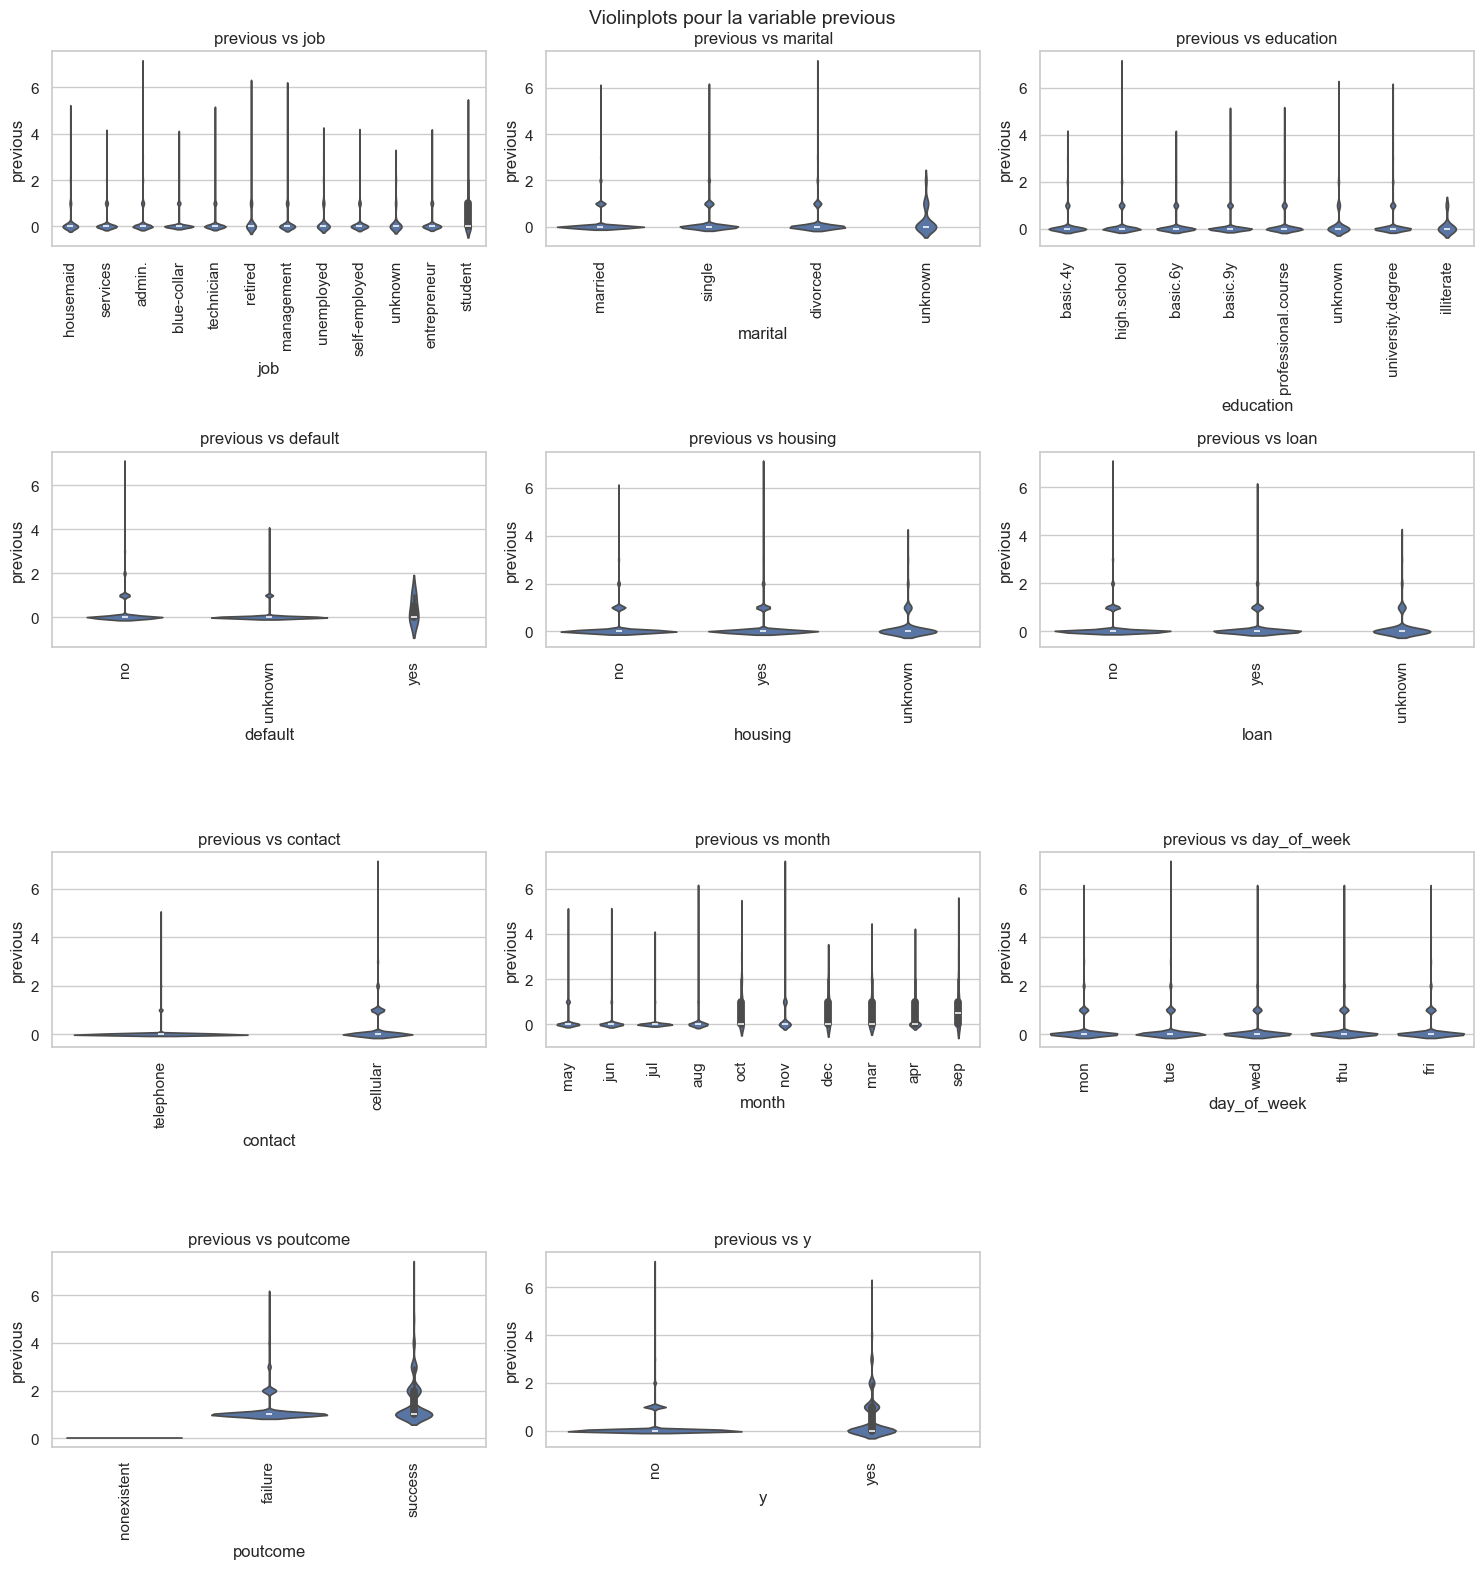

In [42]:
plot_violinplot_per_category(bank_df, categorical_variables, num_variables)

### Interprétation des boxplots et des violinplots par rapport à notre variable target y

#### Boxplots

- En ce qui concerne le boxplot de la vraiable age donné par notre variable target y, il révèle que la plupart des clients qui acceptent de souscrire à un dépot ont une distribution d'age plus dispersé, ce qui traduit la variabilité des profils en terme d'age qui auront à souscrire à un dépot à terme

- En ce qui concerne le boxplot de la vraiable campaign donné par notre variable target y, il révèle que les clients qui acceptent de souscrire à un dépot sont ceux qui ont eu à etre contactés le moins de fois dans la campagne

- En ce qui concerne le boxplot de la vraiable pdays donné par notre variable target y, il révèle qu'autant les clients qui acceptent de souscrire à un dépot à terme et autant ceux qui n'y soucrivent pas n'aviaient pour la plupart jamais été contactés auparavant pour la dernière campagne

- En ce qui concerne le boxplot de la variable previous donné par notre variable target y, il révèle que la plupart des clients qui acceptent de souscrire à un dépot à terme ont été contactés au moins une fois avant le début de la campagne

#### violinplots

- En ce qui concerne le violinplot de la vraiable age donné par notre variable target y, il révèle que la plupart des clients qui acceptent de souscrire à un dépot à terme et tout comme comme qui n'y souscrivent pas ont moins de 40 ans

- En ce qui concerne le violinplot de la vraiable campaign donné par notre variable target y, il révèle que la plupart des clients qui acceptent de souscrire à un dépot à terme ont été contactés au maximun 2 fois

- En ce qui concerne le violinplot de la vraiable pdays donné par notre variable target y, il révèle que la plupart des clients qui ont refusé de souscrire à un dépot à terme n'avient pas éte contactés à la dernière campagne

- En ce qui concerne le violinplot de la vraiable previous donné par notre variable target y, il révèle que la plupart des clients qui ont refusé de souscrire à un dépot à terme n'ont pas été contactés avant cette campagne.



In [46]:
def plot_barplot_per_category(df, categorical_vars, numerical_vars):

    for num_var in numerical_vars:

        n = len(categorical_vars)
        cols = 3
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
        axes = axes.flatten()

        for i, cat_var in enumerate(categorical_vars):
            grouped = df.groupby(cat_var, as_index=False)[num_var].mean()

            sns.barplot(data=grouped, x=cat_var, y=num_var, ax=axes[i])

            axes[i].set_title(f"{num_var} vs {cat_var}")
            axes[i].tick_params(axis="x", rotation=90)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Barplots pour la variable {num_var}", fontsize=14)
        plt.tight_layout()
        plt.show()

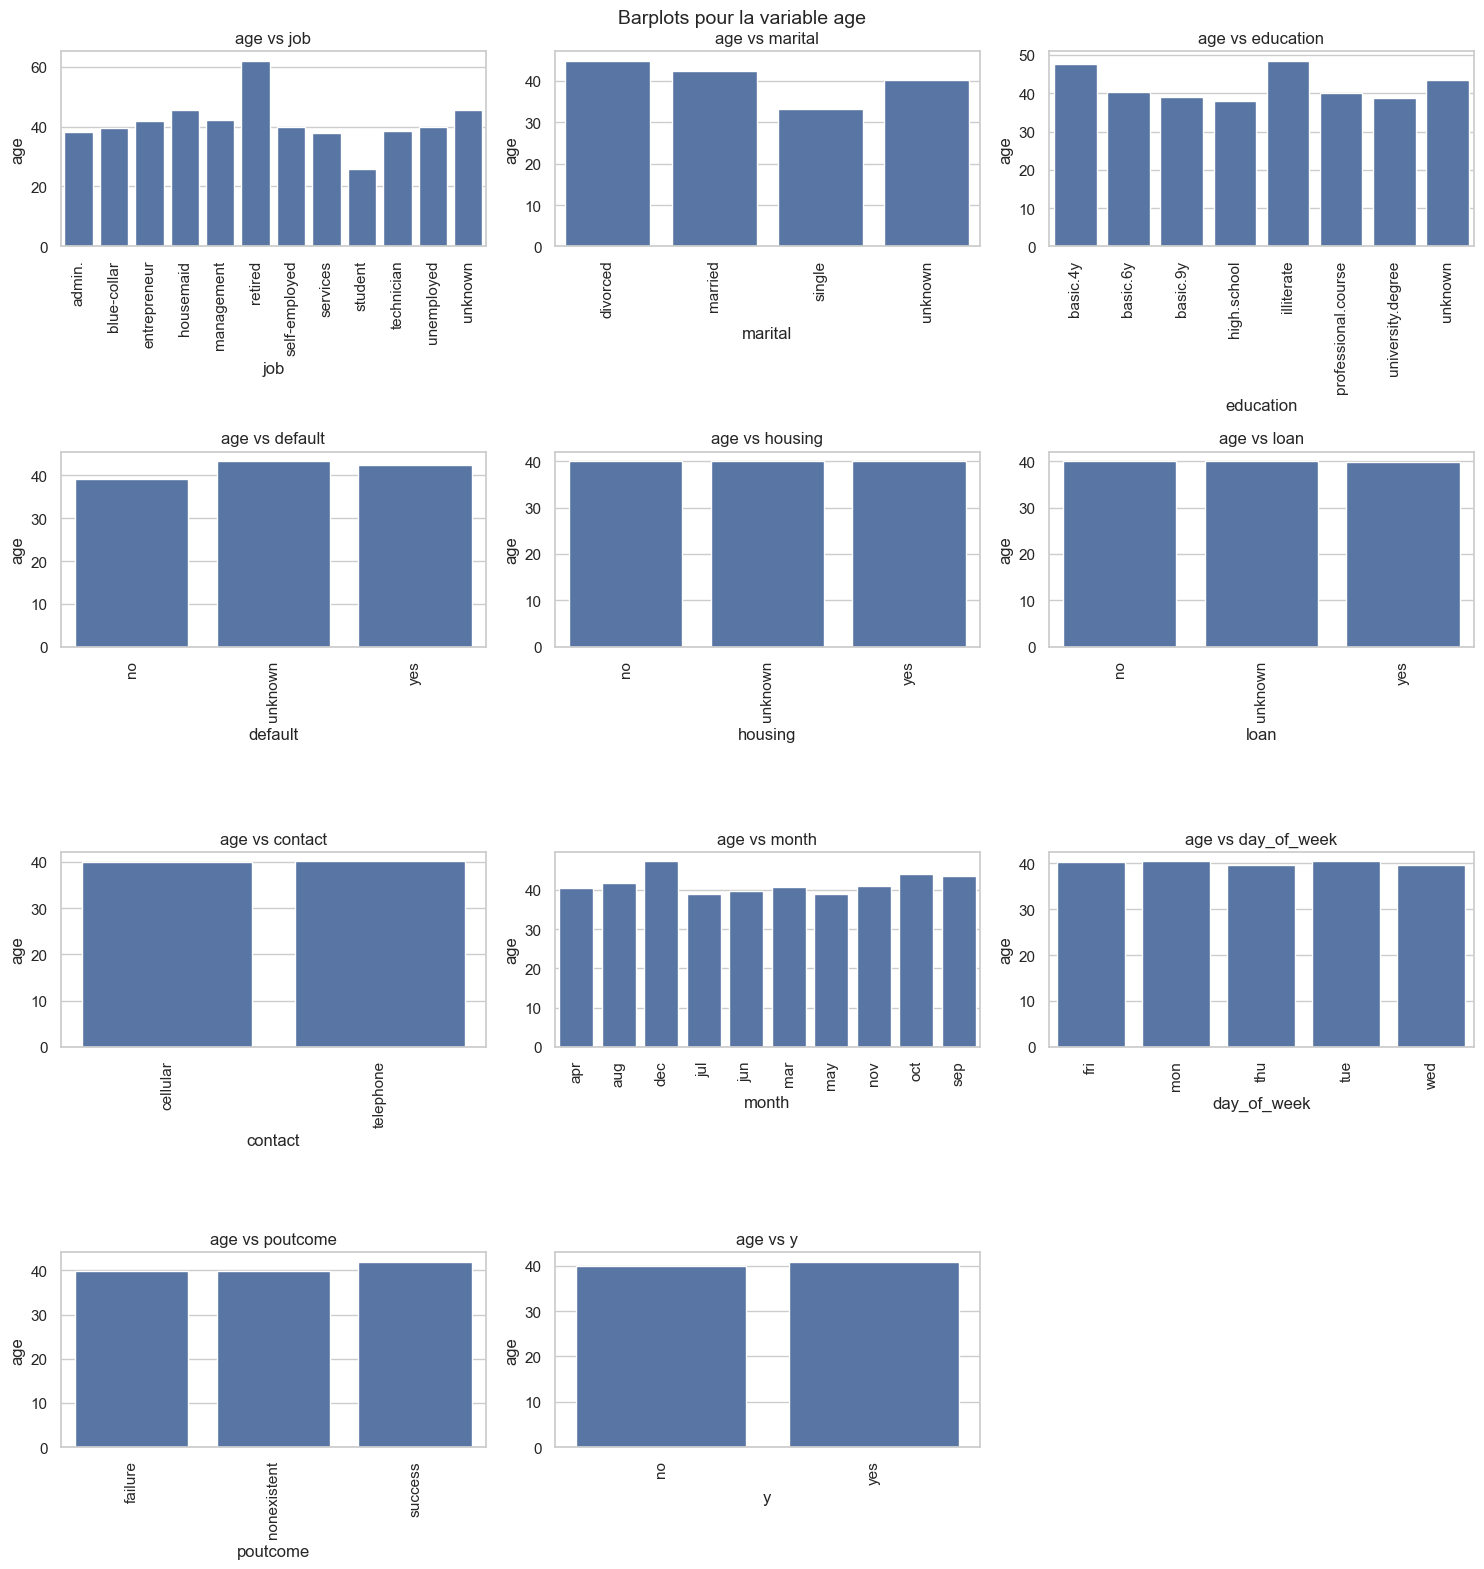

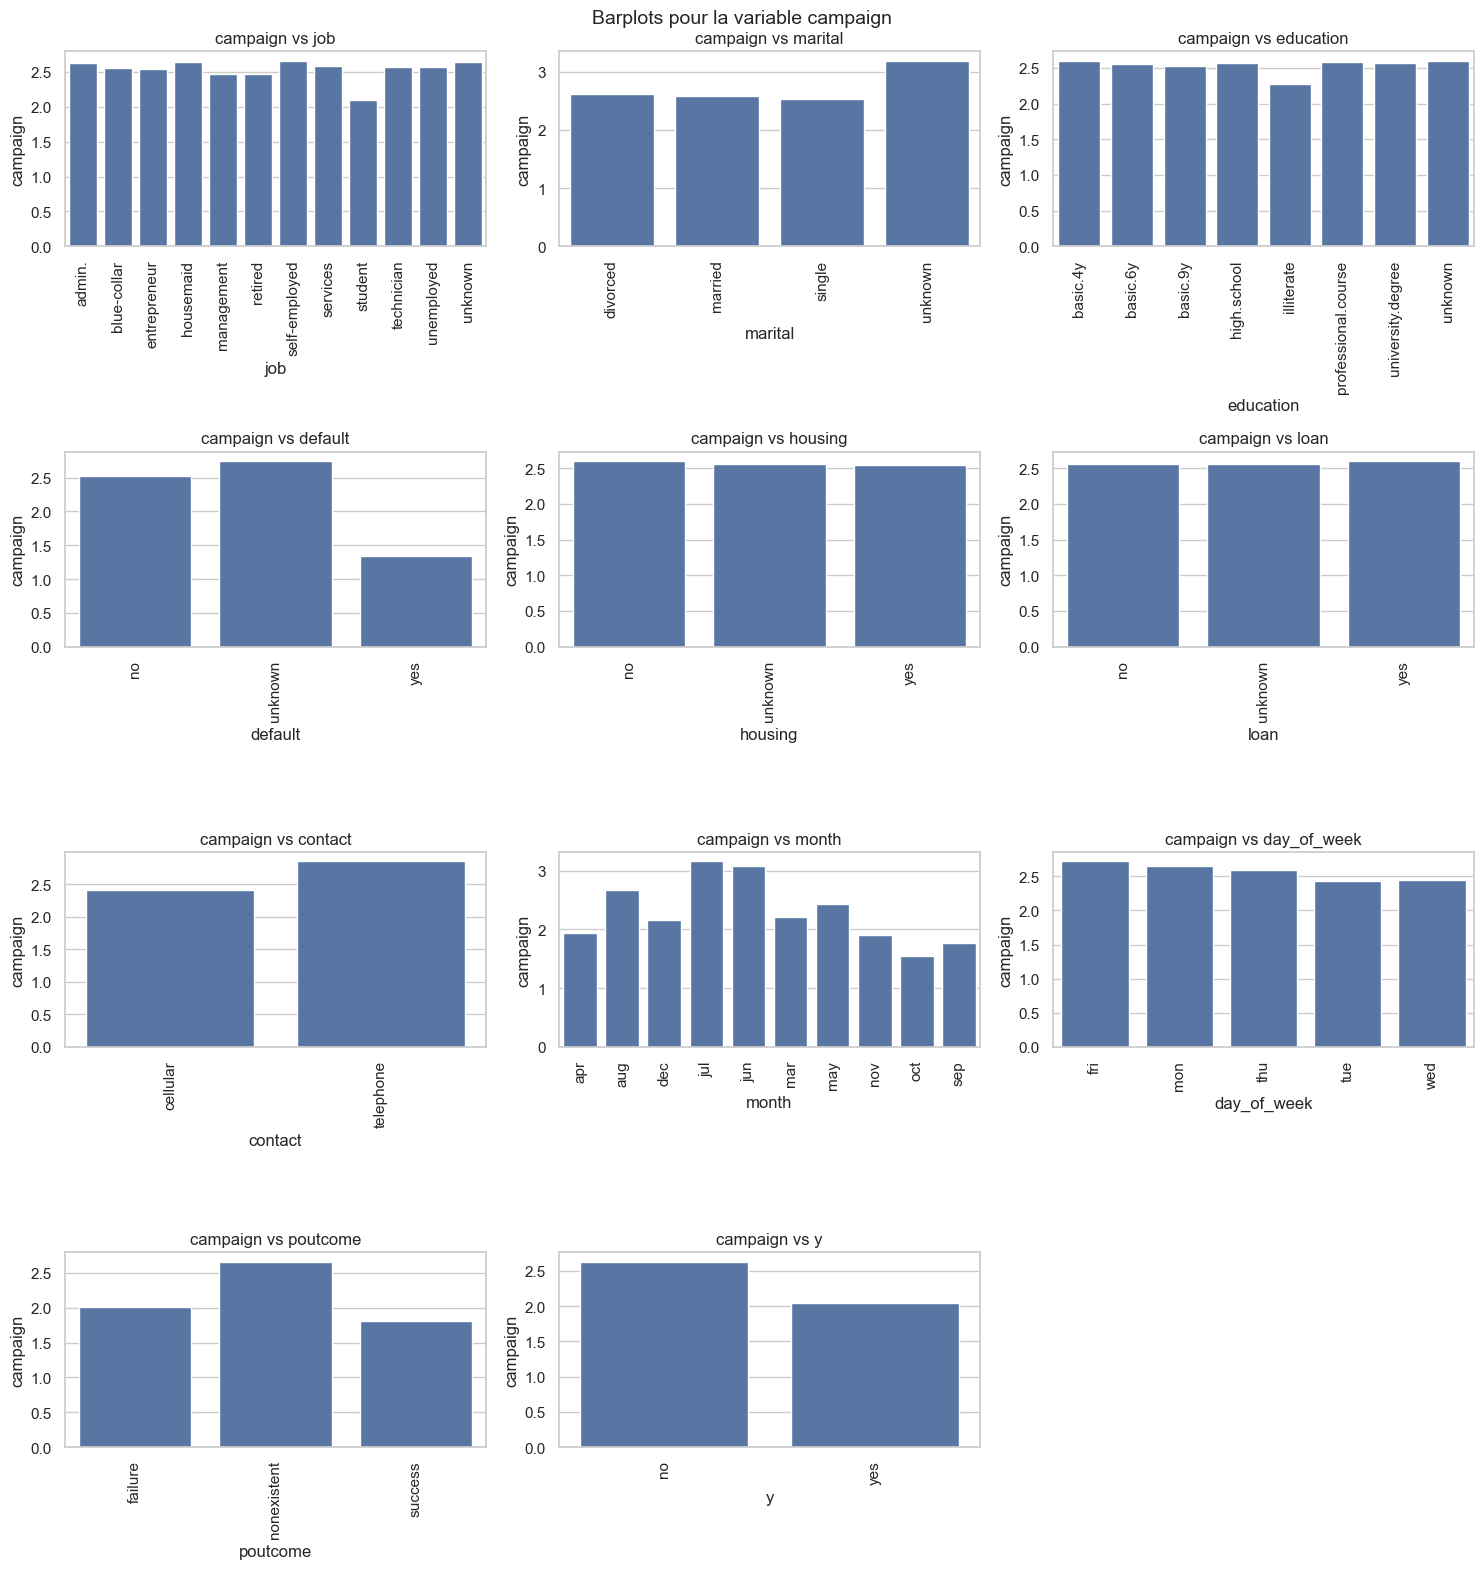

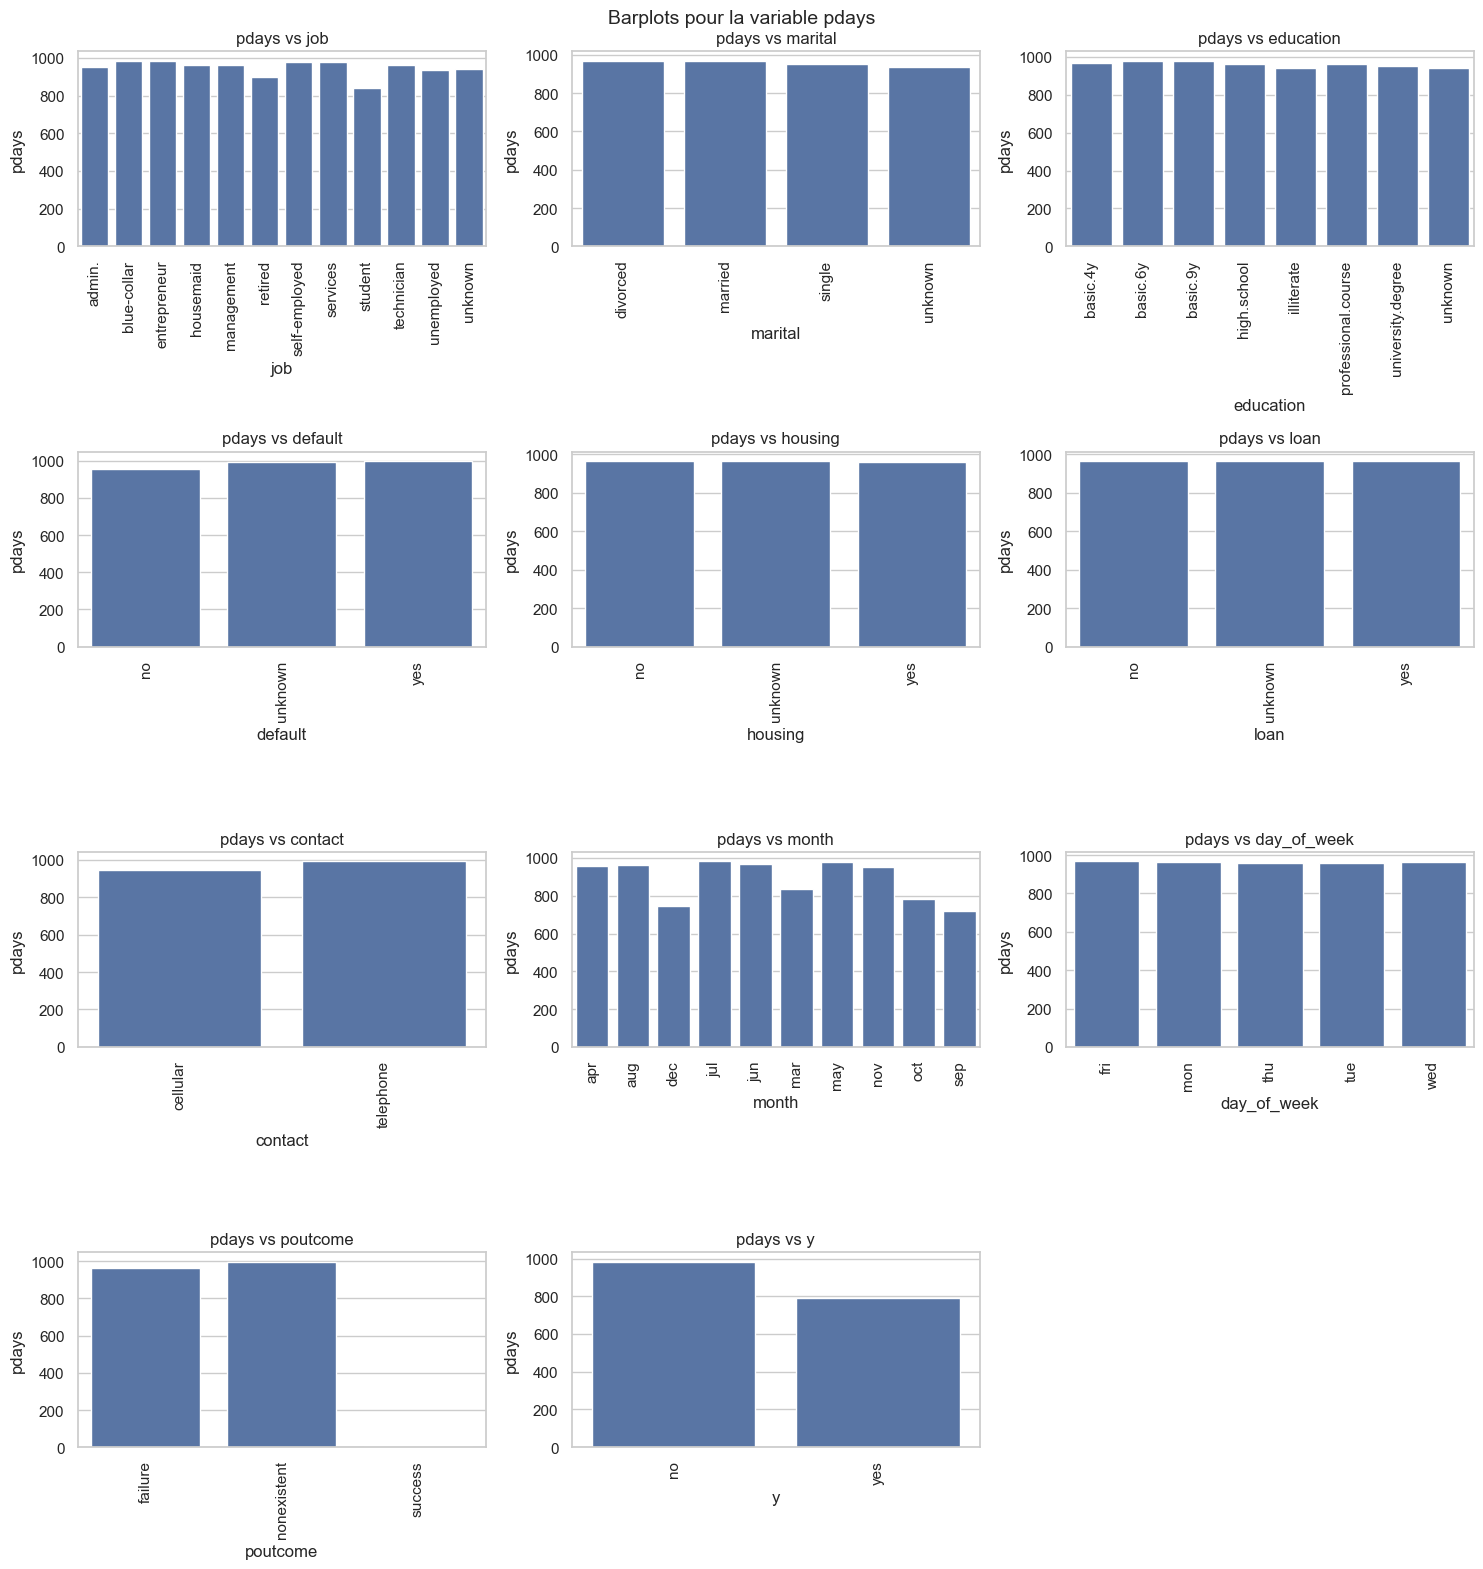

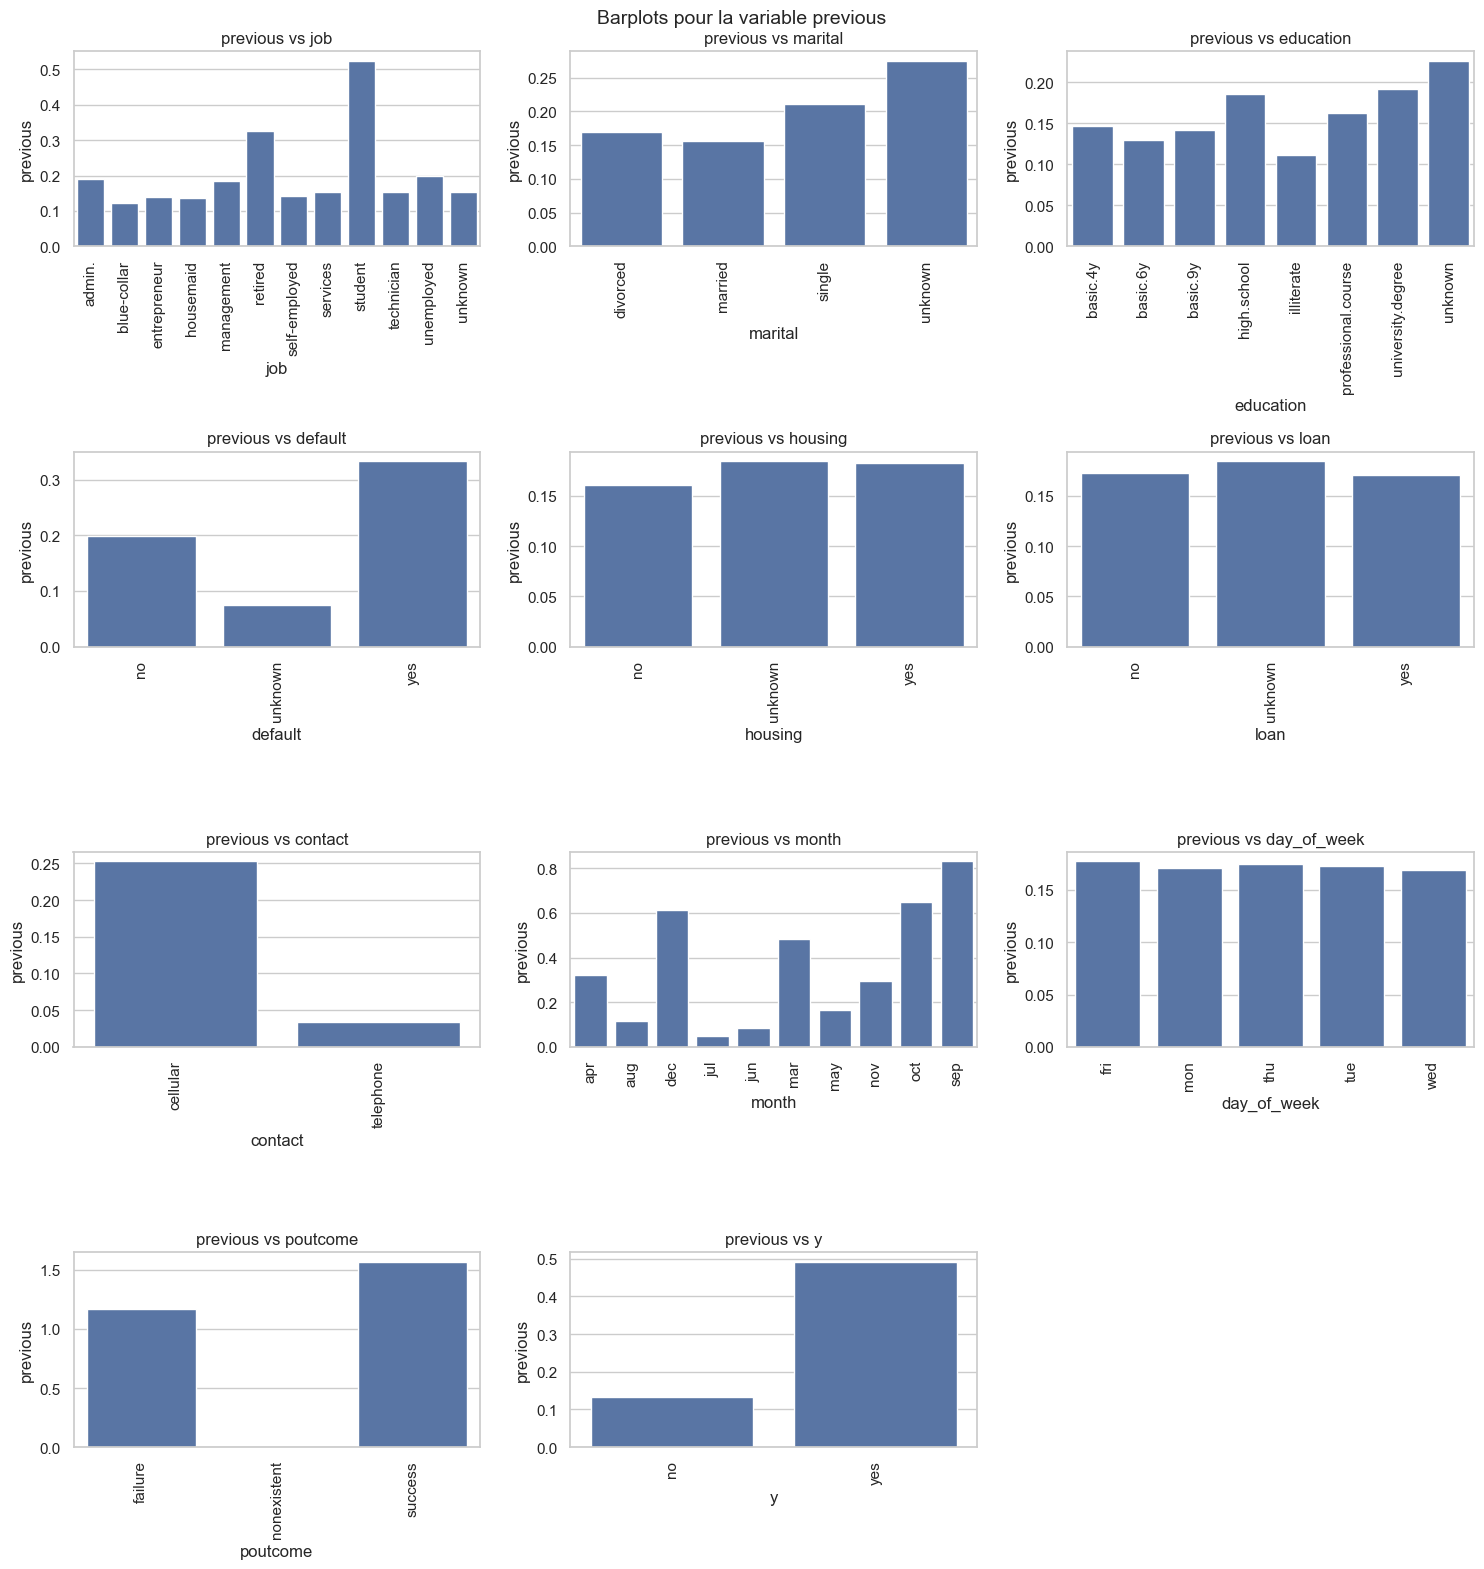

In [47]:
plot_barplot_per_category(bank_df, categorical_variables, num_variables)

# CAS 3 — QUALI ↔ QUALI  

In [56]:
def cross_tab(df, categorical_vars) :

    for cat_var in categorical_vars :
        table = pd.crosstab(df["y"], df[cat_var])
        print(f"Table de contingence entre la variable target y et la variable {cat_var}\n")
        print(f"{table}\n\n")

In [57]:
cross_tab(bank_df, categorical_variables)

Table de contingence entre la variable target y et la variable job

job  admin.  blue-collar  entrepreneur  housemaid  management  retired  \
y                                                                        
no     9070         8616          1332        954        2596     1286   
yes    1352          638           124        106         328      434   

job  self-employed  services  student  technician  unemployed  unknown  
y                                                                       
no            1272      3646      600        6013         870      293  
yes            149       323      275         730         144       37  


Table de contingence entre la variable target y et la variable marital

marital  divorced  married  single  unknown
y                                          
no           4136    22396    9948       68
yes           476     2532    1620       12


Table de contingence entre la variable target y et la variable education

education  basic.

In [58]:
def cross_tab_proportions(df, categorical_vars) :

    for cat_var in categorical_vars :
        table = pd.crosstab(df["y"], df[cat_var])
        table_prop = table.div(table.sum(axis=1), axis=0) * 100
        print(f"Table de contingence entre la variable target y et la variable {cat_var}\n")
        print(f"{table_prop.round(2)}\n\n")

In [59]:
cross_tab_proportions(bank_df, categorical_variables)

Table de contingence entre la variable target y et la variable job

job  admin.  blue-collar  entrepreneur  housemaid  management  retired  \
y                                                                        
no    24.82        23.57          3.64       2.61        7.10     3.52   
yes   29.14        13.75          2.67       2.28        7.07     9.35   

job  self-employed  services  student  technician  unemployed  unknown  
y                                                                       
no            3.48      9.98     1.64       16.45        2.38      0.8  
yes           3.21      6.96     5.93       15.73        3.10      0.8  


Table de contingence entre la variable target y et la variable marital

marital  divorced  married  single  unknown
y                                          
no          11.32    61.28   27.22     0.19
yes         10.26    54.57   34.91     0.26


Table de contingence entre la variable target y et la variable education

education  basic.

In [66]:
def plot_countplot(df, categorical_vars):

    cols = 4
    rows = 3

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, cat_var in enumerate(categorical_vars):
        sns.countplot(x="y", hue=cat_var, data=df, ax=axes[i])
        axes[i].set_title(f"Countplot - {cat_var} vs y")
        axes[i].tick_params(axis="x", rotation=90)

   # supprimer les axes inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

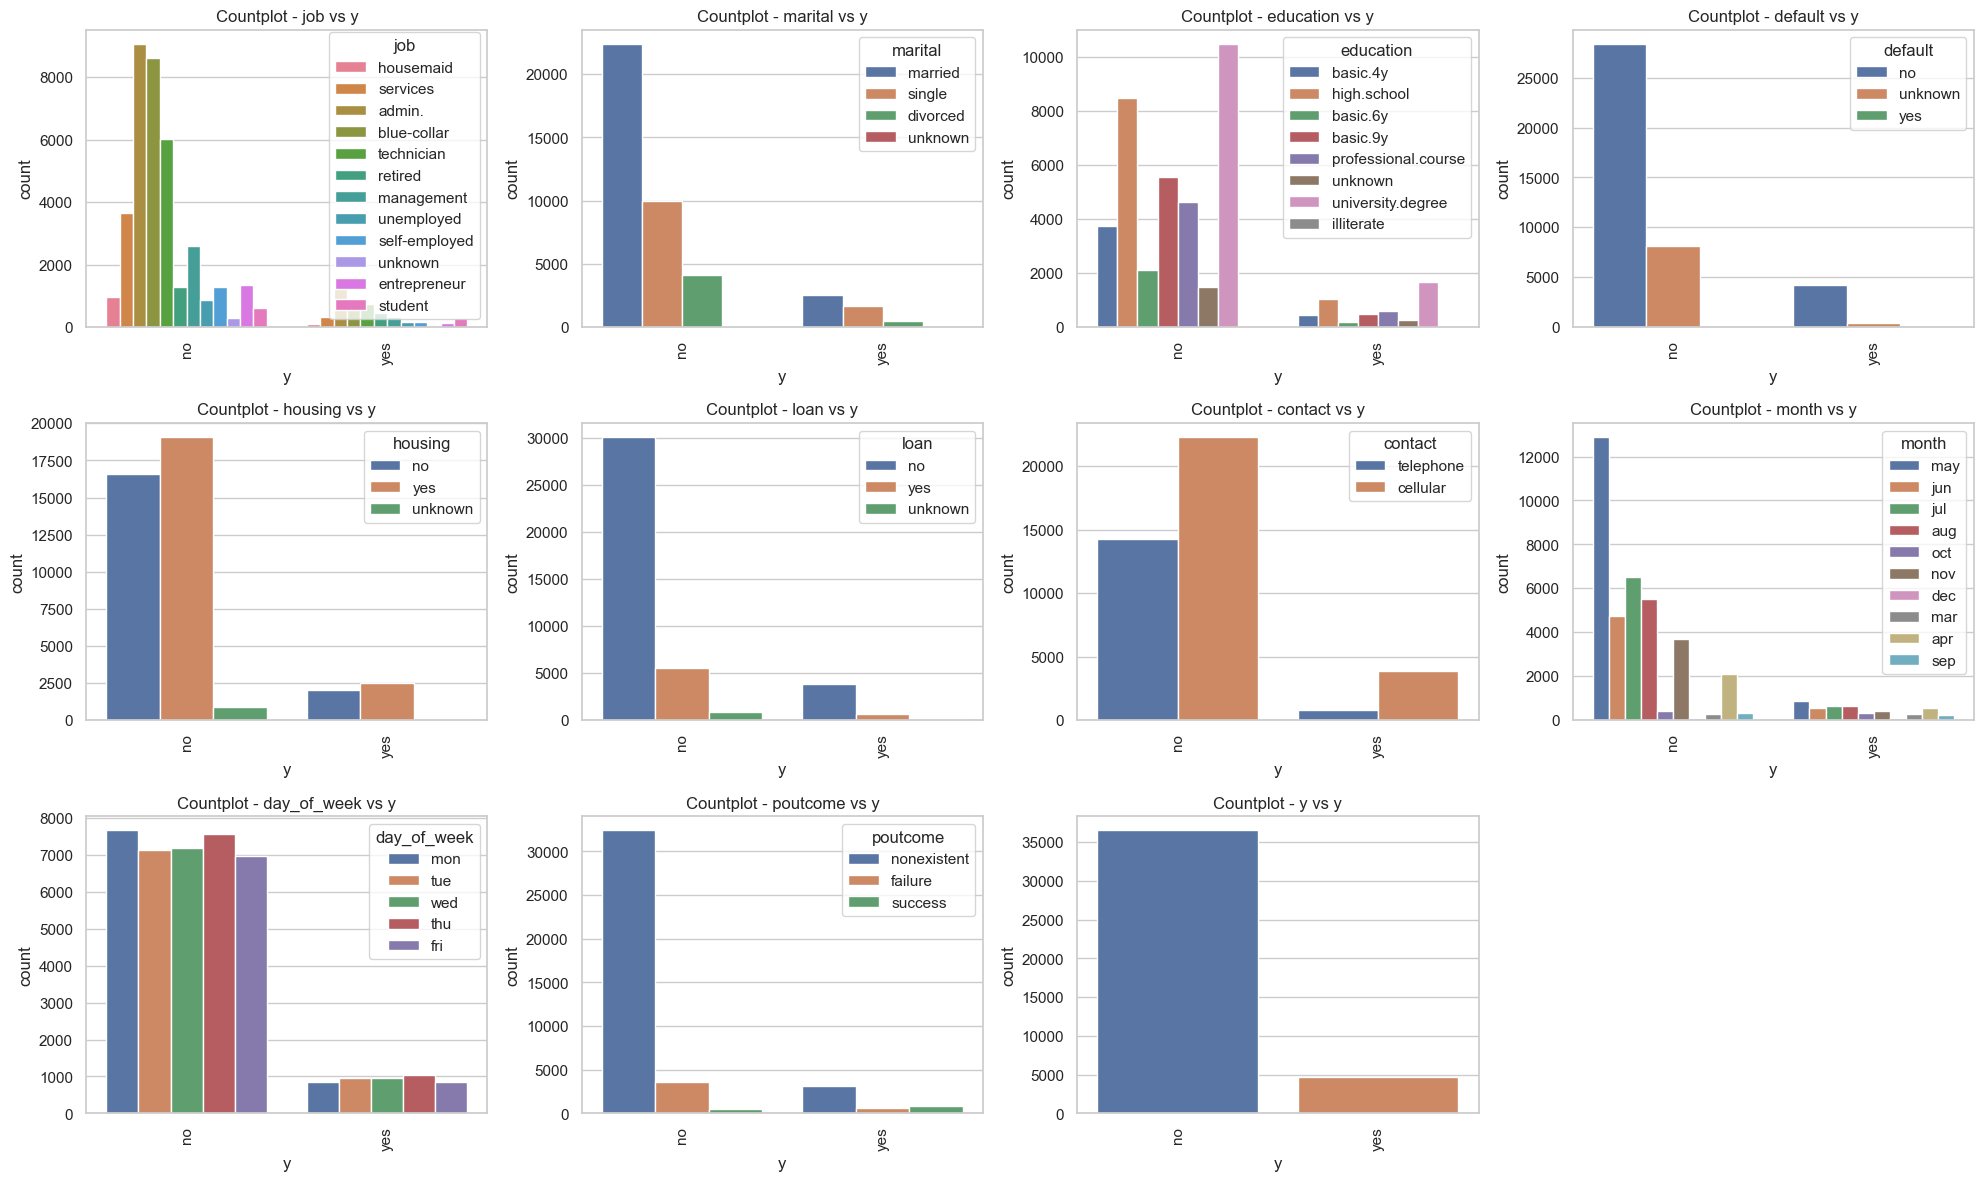

In [67]:
plot_countplot(bank_df, categorical_variables)